# Import Library

In [5]:
!pip install optuna

In [6]:
!pip install catboost

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import json
from shapely.geometry import Polygon
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import optuna
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold, train_test_split
import os
from sklearn.model_selection import train_test_split

In [4]:
# Install dulu
!pip install -q mlxtend

# Import
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import KNNImputer
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector as SFS_sklearn
from mlxtend.feature_selection import SequentialFeatureSelector as SFS_mlxtend

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score


# Analisis

## Data

### Load Data

In [8]:
# 1️⃣ Load Data
df = pd.read_csv("Datafix2124.csv", delimiter=';')
df

,fid,search,found_plac,address,latitude,longitude,year,AOD,BUI,CMI,...,NDBI,NDMI,NDVI,NDWI,Rainfall,SAR_VV,SAVI,WS,SAR_VH,Ratio_VVVH
0,1,TPA KABUPATEN Kab. Klaten,TPS RUSUNAWA KLATEN,8J44+WW6 Jl. Ki Ageng Pemanahan Barenglor Bare...,-7.692686,110.607272,2021,288.489828,-0.587791,0.054020,...,-0.089907,0.089907,0.500853,-0.470447,6.949903,-7.165823,0.292313,0.480309,-14.812621,0.594020
1,2,TPA Cilowong Serang,TPSA Cilowong,V37P+PHW Jalan Raya Cilowong Taktakan Serang C...,-6.138409,106.088707,2021,353.552242,-1.018657,0.088832,...,-0.253071,0.253071,0.767117,-0.681710,8.098960,-7.191023,0.468534,0.214522,-13.937949,0.572089
2,3,TPA Kaburu Kaburu Kepulauan Selayar,TPA Kaburu,WFFG+FRP Jambuiya Kec. Bontomanai Kab. Kepulau...,-6.076295,120.472558,2021,225.557523,-0.738446,0.079245,...,-0.209874,0.209874,0.545418,-0.370783,6.719367,-11.949703,0.368678,0.169498,-15.371342,0.608654
3,4,TPA Milangasri Milangasri Magetan,TPA Milangasri,98FP+936 Waru Kulon Milangasri Panekan Kabupat...,-7.626583,111.326129,2021,246.900252,-0.658173,0.058503,...,-0.101767,0.101767,0.559064,-0.532829,8.165713,-8.074863,0.327357,0.738504,-15.126040,0.591529
4,5,Pengolahan Maggot TPA Blondo BLONDO Semarang,TPA Blondo,QCFW+H8J dusun Merakrejo Blondo Kec. Bawen Kab...,-7.226030,110.441263,2021,255.909923,-0.744433,0.068254,...,-0.144651,0.144651,0.603845,-0.547303,9.205314,-7.176204,0.361184,0.278072,-14.126338,0.505747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,388,TPS Barangka Muna Barat,Lokasi TPA Muna Barat,5HF9+R2J Bungkolo Kec. Barangka Kabupaten Muna...,-4.835037,122.557525,2024,248.898283,-0.812952,0.082793,...,-0.162180,0.162180,0.657718,-0.582866,5.600993,-7.366698,0.403620,0.867067,-13.875929,0.456861
1564,389,TPS Blang Beururu Bireuen,TPS Meunasah Baray,59RH+M56 Meunasah Bar. Kec. Simpang Mamplam Ka...,5.192322,96.295652,2024,263.628108,-0.779471,0.071089,...,-0.187889,0.187889,0.594501,-0.538713,3.979358,-8.615654,0.369431,0.235210,-13.873730,0.412627
1565,390,TPST SAMPAR JAJONG Sumbawa Barat,TPST Sampar Jajong,4Q5R+VW2 Benete Kec. Maluk Kabupaten Sumbawa B...,-8.890373,116.792265,2024,234.130676,-0.538289,0.046451,...,-0.041723,0.041723,0.506495,-0.515893,4.364092,-8.782869,0.284367,1.561976,-14.625936,0.576091
1566,391,TPST W4C Cimahi,Tempat Pengolahan Sampah Terpadu/TPST,4H63+6PV Jl. Abdul Halim Cigugur Tengah Kec. C...,-6.889390,107.545288,2024,342.494416,-0.290017,0.027083,...,0.037576,-0.037576,0.327990,-0.361023,6.107946,-5.731136,0.184145,0.113199,-14.622881,0.532230


In [9]:
df = df.drop(['CO', 'Humid', 'WS', 'Rainfall'], axis=1)

## Preprocessing

### Cek Missing

In [10]:
data = df.copy()
# Cek jumlah missing values
print("Missing values sebelum imputasi:\n", data.isnull().sum())

Missing values sebelum imputasi:
 fid             0
search          0
found_plac      0
address         0
latitude        0
longitude       0
year            0
AOD             0
BUI            40
CMI            40
Ch4           515
DDI            40
EVI            40
Elevation       4
GEMI           40
LST           327
MSAVI          40
NDBI           40
NDMI           40
NDVI           40
NDWI           40
SAR_VV          0
SAVI           40
SAR_VH          0
Ratio_VVVH      0
dtype: int64


### Imputasi Interpolasi, Transformasi Min-Max, Kategorisasi 3MSD, Smotetomek

In [11]:
# Hitung jumlah missing values pada kolom 'CH4' per tahun
missing_ch4_per_year = data.groupby('year')['Ch4'].apply(lambda x: x.isnull().sum())

print("\nJumlah data missing CH4 per tahun:\n", missing_ch4_per_year)


Jumlah data missing CH4 per tahun:
 year
2021    173
2022    201
2023     66
2024     75
Name: Ch4, dtype: int64


In [12]:
# Hapus baris yang memiliki nilai NaN di kolom 'Ch4'
data = data.dropna(subset=['Ch4'])
data['AOD'] = data['AOD'] * 0.001
data['EVI'] = data['EVI'].where(data['EVI'].between(-1, 1), np.nan)

# Cek jumlah missing values setelah penghapusan
print("\nMissing values setelah menghapus baris dengan NaN di 'Ch4':\n", data.isnull().sum())


Missing values setelah menghapus baris dengan NaN di 'Ch4':
 fid             0
search          0
found_plac      0
address         0
latitude        0
longitude       0
year            0
AOD             0
BUI            21
CMI            21
Ch4             0
DDI            21
EVI            34
Elevation       1
GEMI           21
LST           156
MSAVI          21
NDBI           21
NDMI           21
NDVI           21
NDWI           21
SAR_VV          0
SAVI           21
SAR_VH          0
Ratio_VVVH      0
dtype: int64


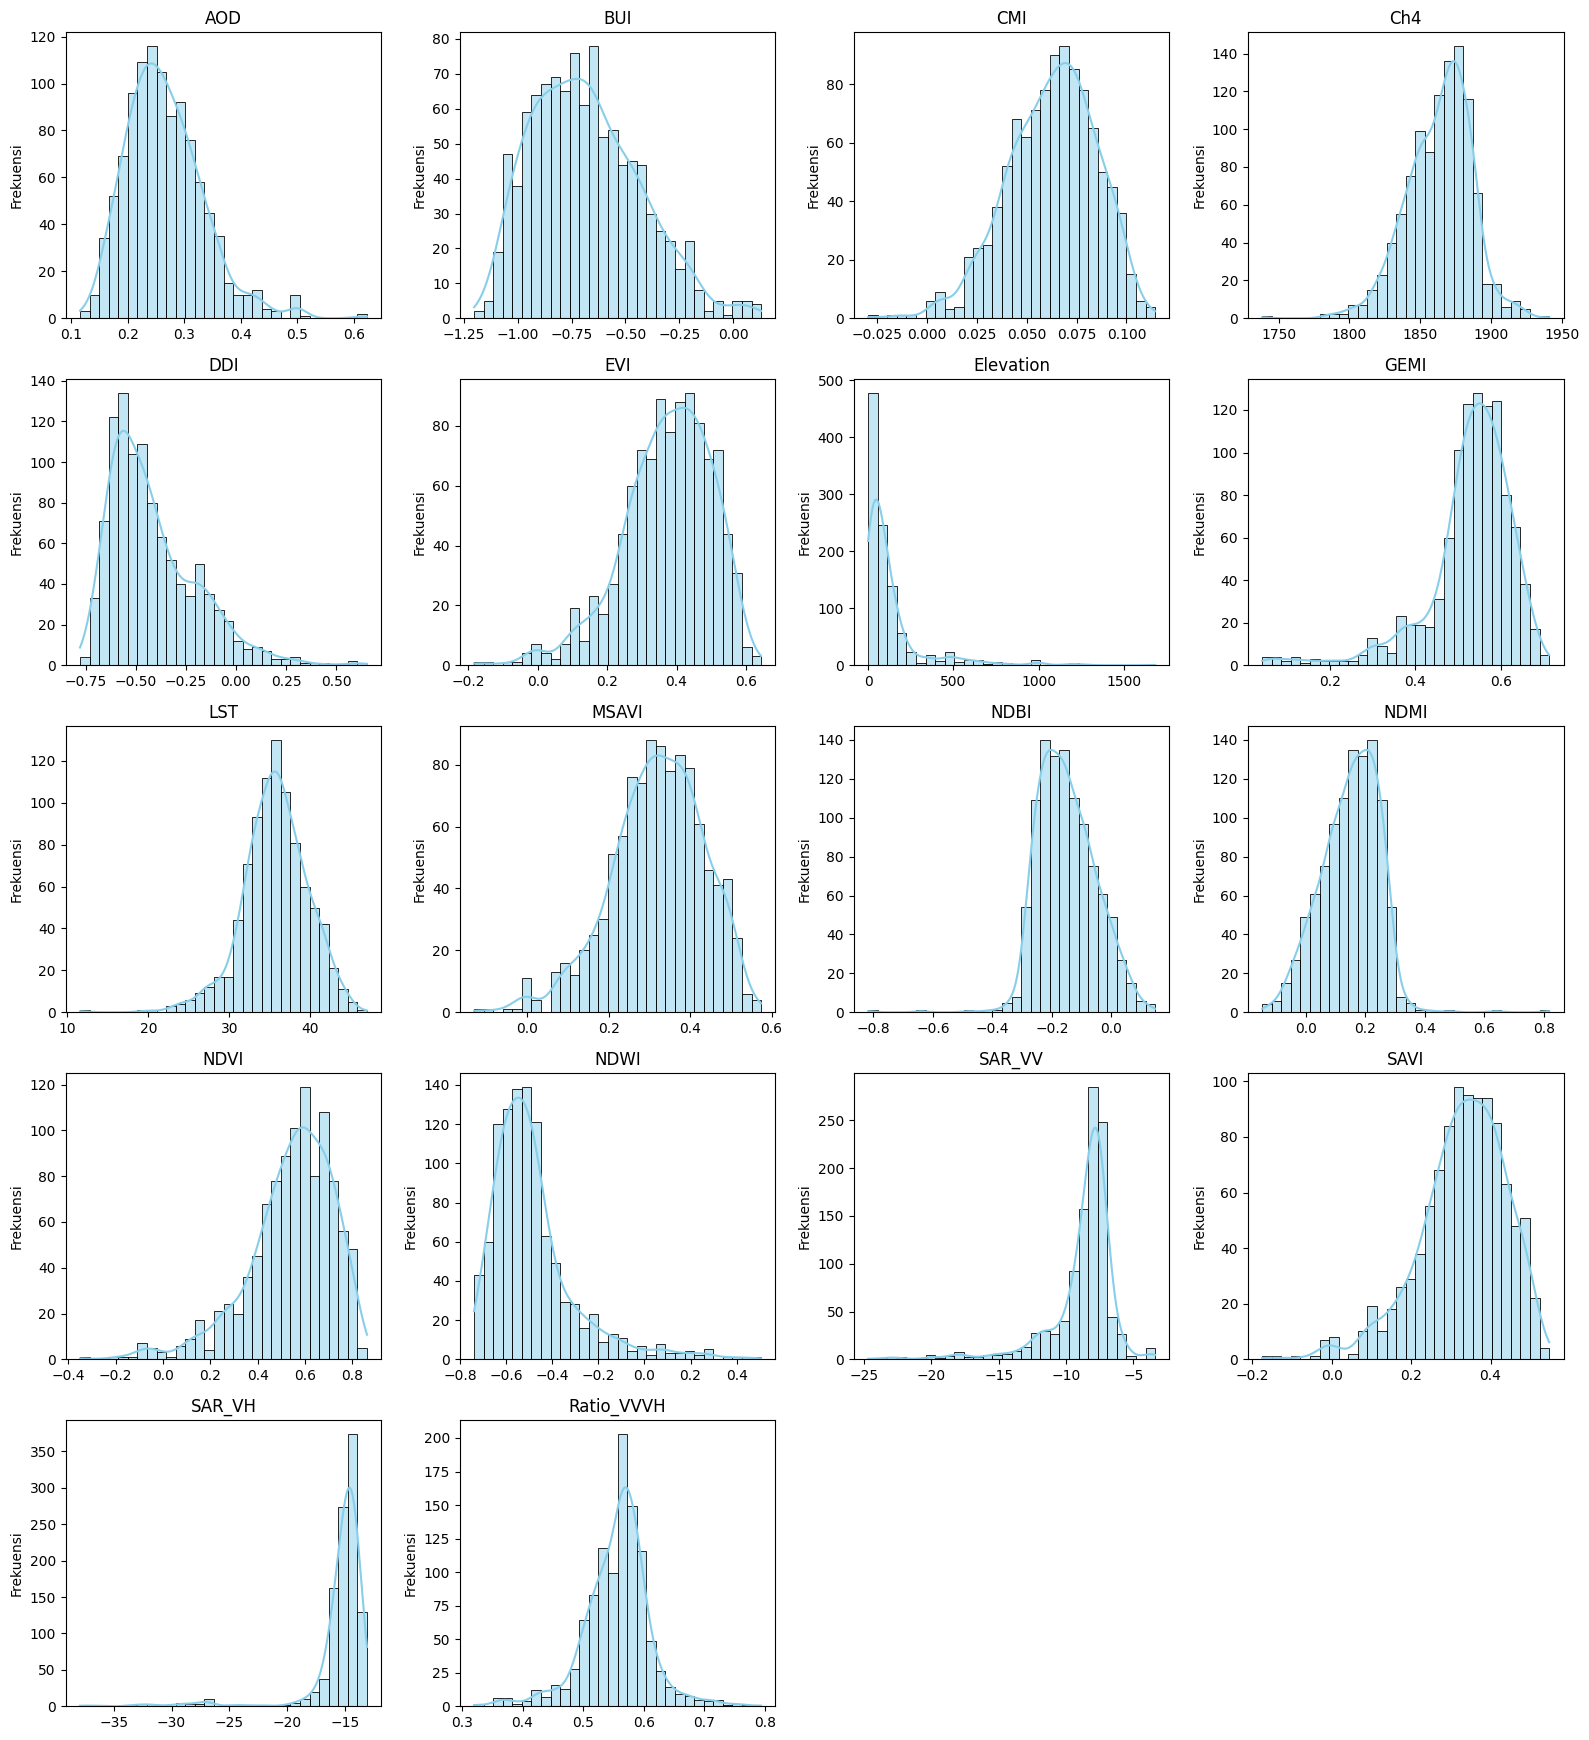

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Contoh struktur DataFrame, ganti dengan data kamu
# df = pd.read_csv('nama_file.csv')

# Daftar variabel yang kamu punya
variables = ['AOD', 'BUI', 'CMI', 'Ch4', 'DDI', 'EVI', 'Elevation', 'GEMI', 'LST',
             'MSAVI', 'NDBI', 'NDMI', 'NDVI', 'NDWI', 'SAR_VV', 'SAVI', 'SAR_VH', 'Ratio_VVVH']

# Ukuran layout plot
n_cols = 4
n_rows = -(-len(variables) // n_cols)  # ceiling division

# Buat plot
plt.figure(figsize=(n_cols*4, n_rows*3.5))
for i, var in enumerate(variables, 1):
    if data[var].dropna().nunique() > 0:  # hanya plot jika ada variasi data
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data[var].dropna(), bins=30, kde=True, color='skyblue')
        plt.title(var)
        plt.xlabel('')
        plt.ylabel('Frekuensi')
    else:
        continue

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# ==== 1. Bagi train-test berdasarkan Tahun ====
train_data = data[data['year'] <= 2023].copy()
test_data = data[data['year'] == 2024].copy()

# ==== 2. Pisahkan fitur dan target ====
drop_cols = ['Ch4', 'year', 'fid', 'search', 'found_plac', 'address', 'latitude', 'longitude']
X_train = train_data.drop(columns=drop_cols)
X_test = test_data.drop(columns=drop_cols)

y_train_cont = train_data['Ch4']
y_test_cont = test_data['Ch4']

# ==== 3. Imputasi dengan interpolasi linear ====
X_train_imputed = X_train.interpolate(method='linear', axis=0, limit_direction='both')
X_test_imputed = X_test.interpolate(method='linear', axis=0, limit_direction='both')

# ==== 4. Scaling dengan MinMax ====
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

# ==== 5. Kategorisasi berdasarkan Mean dan Standar Deviasi ====
mean = y_train_cont.mean()
std = y_train_cont.std()

low_threshold = mean - 1.5 * std
high_threshold = mean + 1.5 * std

# Fungsi kategorisasi
def categorize(value):
    if value <= low_threshold:
        return 0  # Rendah
    elif value >= high_threshold:
        return 2  # Tinggi
    else:
        return 1  # Sedang

y_train_cat = y_train_cont.apply(categorize)
y_test_cat = y_test_cont.apply(categorize)

# ==== 6. SMOTETomek ====
smote = SMOTE(k_neighbors=2, random_state=42)
smote_tomek = SMOTETomek(smote=smote, random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_scaled, y_train_cat)

# ==== 7. Final Output ====
X_train = X_resampled
y_train = y_resampled.astype('category')

X_test = X_test_scaled
y_test = y_test_cat.astype('category')


In [15]:
print("Mean = ", mean)
print("Std = ", std)

Mean =  1859.40687578125
Std =  22.12009487858007


In [16]:
# prompt: hitung na di y_test

print(f"\nJumlah nilai NaN di kolom y_test adalah: {y_test.isnull().sum()}")


Jumlah nilai NaN di kolom y_test adalah: 0


In [17]:
X_train

,AOD,BUI,CMI,DDI,EVI,Elevation,GEMI,LST,MSAVI,NDBI,NDMI,NDVI,NDWI,SAR_VV,SAVI,SAR_VH,Ratio_VVVH
0,0.443182,0.463686,0.583213,0.151871,0.626512,0.106587,0.700315,0.781064,0.577636,0.754075,0.245925,0.702478,0.216071,0.822268,0.657748,0.927567,0.569054
1,0.610140,0.139089,0.825774,0.197689,0.867667,0.080279,0.866224,0.556838,0.870065,0.585049,0.414951,0.922009,0.046490,0.821086,0.905466,0.971590,0.521756
2,0.336458,0.410663,0.614449,0.119416,0.654988,0.204996,0.729430,0.675316,0.628264,0.741788,0.258212,0.750473,0.165997,0.779639,0.707010,0.911792,0.563681
3,0.359578,0.345678,0.682393,0.179293,0.718115,0.292252,0.763195,0.665199,0.689243,0.697364,0.302636,0.787394,0.154378,0.821781,0.754562,0.962108,0.378680
4,0.507395,0.323723,0.683909,0.131825,0.730846,0.135818,0.756867,0.605733,0.663349,0.670110,0.329890,0.790775,0.173739,0.762693,0.735792,0.952783,0.622860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,0.214978,0.324171,0.644517,0.283231,0.696880,0.574767,0.763094,0.667151,0.683990,0.678014,0.321986,0.795320,0.124919,0.802042,0.751440,0.942162,0.588066
1971,0.756684,0.695655,0.409838,0.302456,0.484528,0.028709,0.620363,0.873832,0.425728,0.866690,0.133310,0.542804,0.319829,0.900907,0.505452,0.974768,0.211703
1972,0.720147,0.665726,0.412699,0.258981,0.467933,0.015381,0.546602,0.750782,0.429142,0.819303,0.180697,0.530486,0.359706,0.629281,0.506702,0.716805,0.646281
1973,0.265888,0.521717,0.617036,0.198587,0.663952,0.148457,0.776815,0.874773,0.620797,0.823571,0.176429,0.703018,0.192891,0.729151,0.690218,0.896150,0.565509


In [18]:
from collections import Counter

print("Sebelum SMOTETomek:", Counter(y_train_cat))
print("Sesudah SMOTETomek:", Counter(y_resampled))


Sebelum SMOTETomek: Counter({1: 659, 0: 48, 2: 29})
Sesudah SMOTETomek: Counter({2: 659, 1: 658, 0: 658})


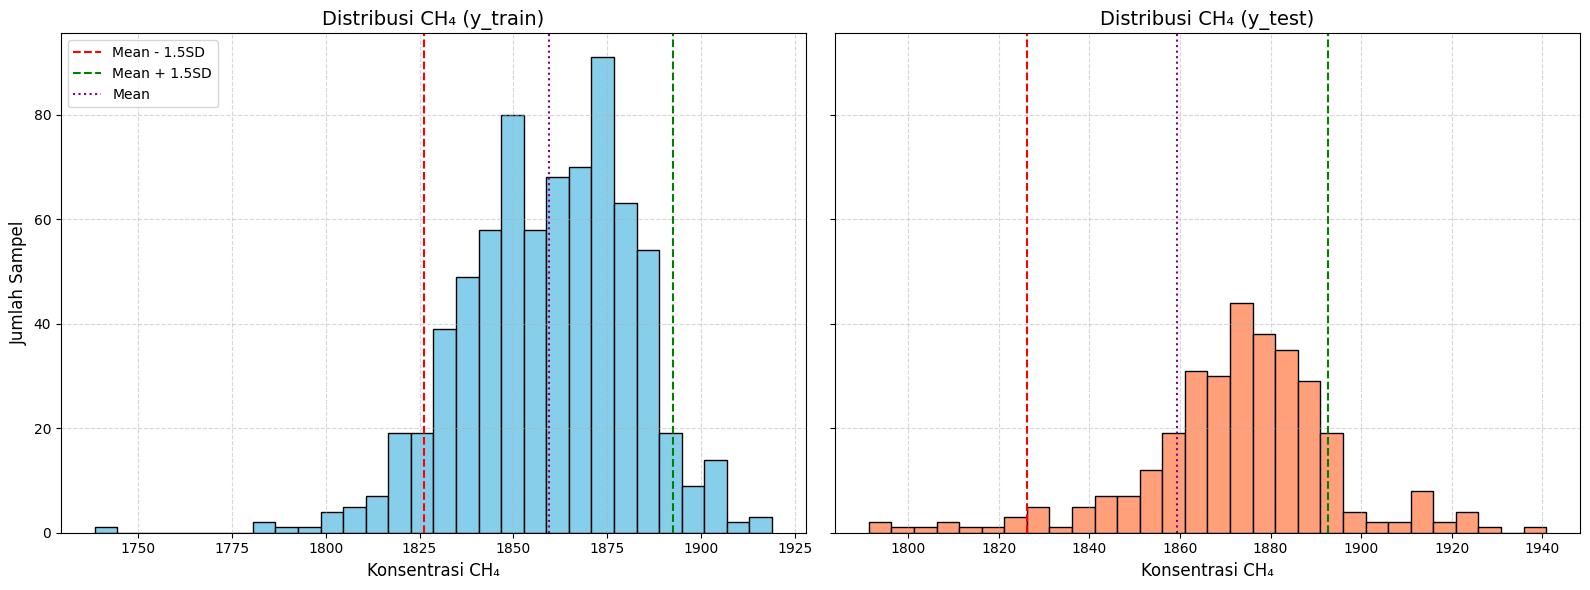

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Hitung mean dan standar deviasi dari y_train
mean = y_train_cont.mean()
std = y_train_cont.std()

# Tentukan batas bawah dan atas kategori
low_threshold = mean - 1.5 * std
high_threshold = mean + 1.5 * std

# Buat figure dengan dua subplot
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ==== Plot y_train ====
axs[0].hist(y_train_cont, bins=30, color="#87CEEB", edgecolor='black')
axs[0].set_title("Distribusi CH₄ (y_train)", fontsize=14)
axs[0].set_xlabel("Konsentrasi CH₄", fontsize=12)
axs[0].set_ylabel("Jumlah Sampel", fontsize=12)

# Garis mean, low, high
axs[0].axvline(x=low_threshold, color='red', linestyle='--', label='Mean - 1.5SD')
axs[0].axvline(x=high_threshold, color='green', linestyle='--', label='Mean + 1.5SD')
axs[0].axvline(x=mean, color='purple', linestyle=':', label='Mean')

# ==== Plot y_test ====
axs[1].hist(y_test_cont, bins=30, color="#FFA07A", edgecolor='black')
axs[1].set_title("Distribusi CH₄ (y_test)", fontsize=14)
axs[1].set_xlabel("Konsentrasi CH₄", fontsize=12)

# Garis batas yang sama
axs[1].axvline(x=low_threshold, color='red', linestyle='--')
axs[1].axvline(x=high_threshold, color='green', linestyle='--')
axs[1].axvline(x=mean, color='purple', linestyle=':')

# Tambahkan legend dan grid
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [20]:
y_train

,Ch4
0,1
1,1
2,1
3,1
4,1
...,...
1970,2
1971,2
1972,2
1973,2


In [21]:
# prompt: di y_train dan y_test hitung tiap kategori

print("Distribusi kategori di y_train:")
print(y_train.value_counts())

print("\nDistribusi kategori di y_test:")
print(y_test.value_counts())

Distribusi kategori di y_train:
Ch4
2    659
0    658
1    658
Name: count, dtype: int64

Distribusi kategori di y_test:
Ch4
1    274
2     32
0     11
Name: count, dtype: int64


## Statistik Deskriptif

In [22]:
print("\nJumlah data per kategori sebelum resampling:")
print(y_train_cat.value_counts())

print("\nJumlah data per kategori sesudah resampling:")
print(y_resampled.value_counts())



Jumlah data per kategori sebelum resampling:
Ch4
1    659
0     48
2     29
Name: count, dtype: int64

Jumlah data per kategori sesudah resampling:
Ch4
2    659
1    658
0    658
Name: count, dtype: int64


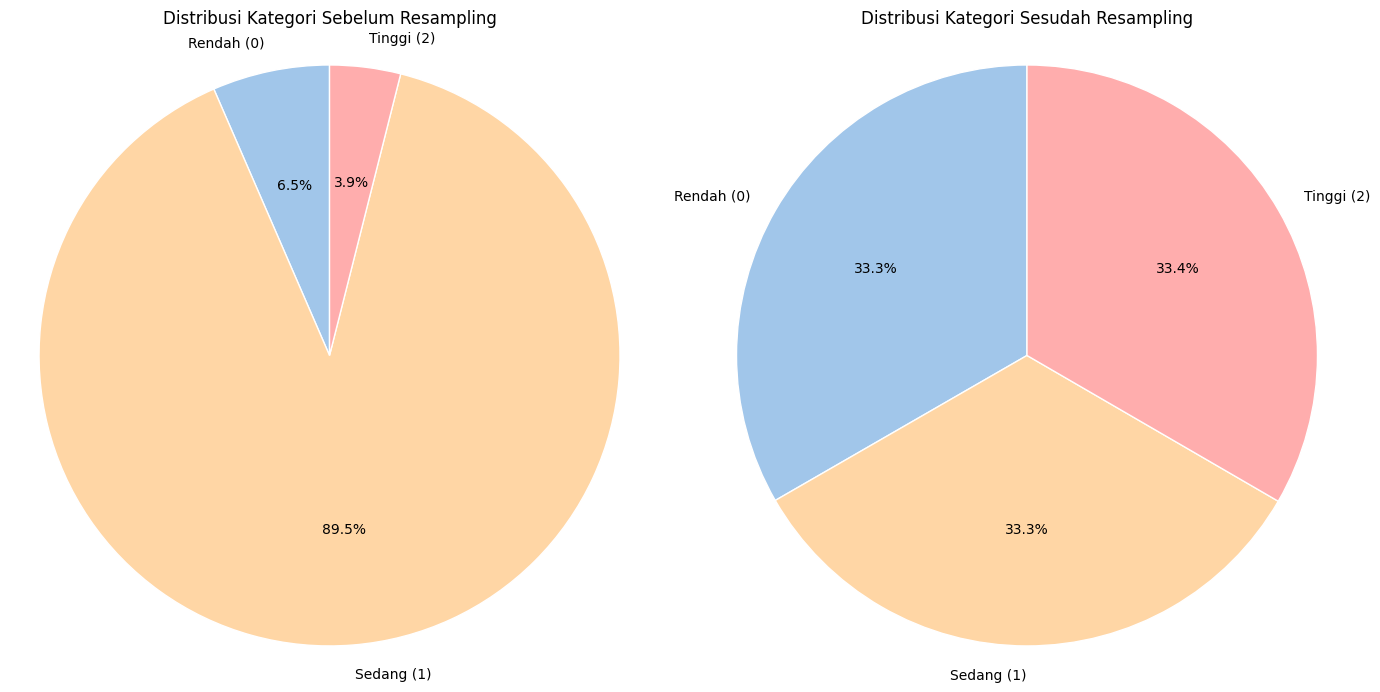

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah data per kategori sebelum resampling
before_resampling_counts = y_train_cat.value_counts().sort_index()

# Hitung jumlah data per kategori sesudah resampling
after_resampling_counts = y_resampled.value_counts().sort_index()

# Label untuk pie chart
labels = ['Rendah (0)', 'Sedang (1)', 'Tinggi (2)']

# Warna pastel yang cute dan soft
colors = ['#A1C6EA', '#FFD6A5', '#FFADAD']

# Buat figure dengan dua subplots (satu untuk sebelum, satu untuk sesudah)
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# Pie chart sebelum resampling
axs[0].pie(before_resampling_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
axs[0].set_title('Distribusi Kategori Sebelum Resampling')
axs[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Pie chart sesudah resampling
axs[1].pie(after_resampling_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
axs[1].set_title('Distribusi Kategori Sesudah Resampling')
axs[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()


In [24]:
print(f"Jumlah data train: {len(X_train)}")
print(f"Jumlah data test: {len(X_test)}")

Jumlah data train: 1975
Jumlah data test: 317


In [25]:
# Statistik Deskriptif sebelum transformasi (menggunakan X_train_imputed yang sudah diimputasi tapi belum di-transform)
print("Statistik Deskriptif Data X Sebelum Transformasi (Setelah Imputasi):")
print(X_train_imputed.describe())

# Statistik Deskriptif setelah transformasi (menggunakan X_train_final yang sudah diimputasi dan di-MinMax)
print("\nStatistik Deskriptif Data X Sesudah Transformasi (Setelah Imputasi dan MinMax):")
print(X_train.describe())


Statistik Deskriptif Data X Sebelum Transformasi (Setelah Imputasi):
              AOD         BUI         CMI         DDI         EVI  \
count  736.000000  736.000000  736.000000  736.000000  736.000000   
mean     0.254128   -0.682803    0.062213   -0.406183    0.371779   
std      0.064143    0.250398    0.021963    0.222868    0.126235   
min      0.115785   -1.203284   -0.029681   -0.779051   -0.183320   
25%      0.207351   -0.885451    0.047073   -0.577143    0.297934   
50%      0.246563   -0.709198    0.063922   -0.459086    0.382918   
75%      0.293227   -0.513072    0.077583   -0.270438    0.465350   
max      0.505478    0.124110    0.113836    0.654920    0.636710   

         Elevation        GEMI         LST       MSAVI        NDBI  \
count   736.000000  736.000000  736.000000  736.000000  736.000000   
mean    129.420693    0.527597   35.864187    0.317142   -0.149137   
std     195.548239    0.099009    3.977356    0.113343    0.097265   
min       0.000000    0.04215

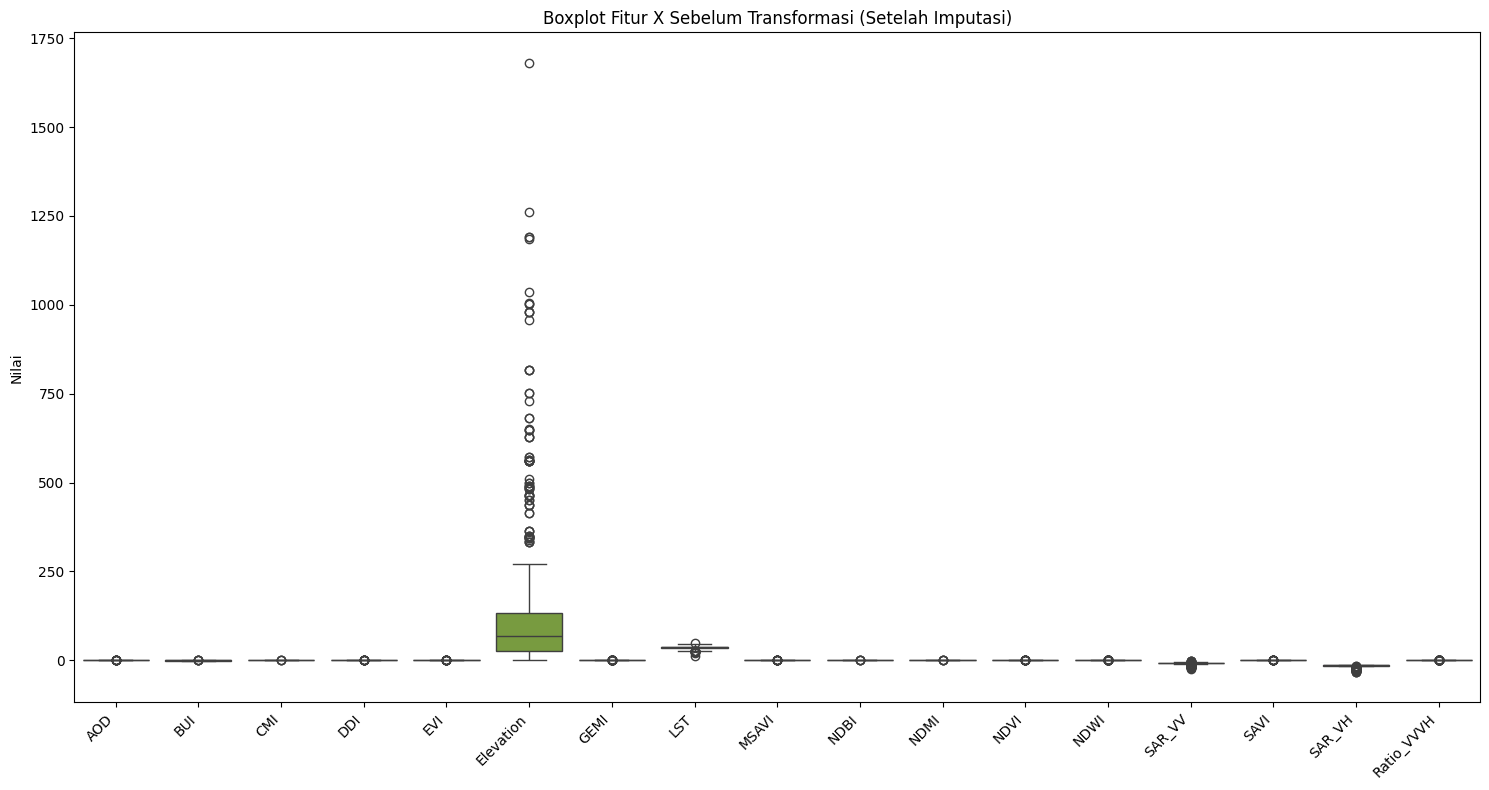

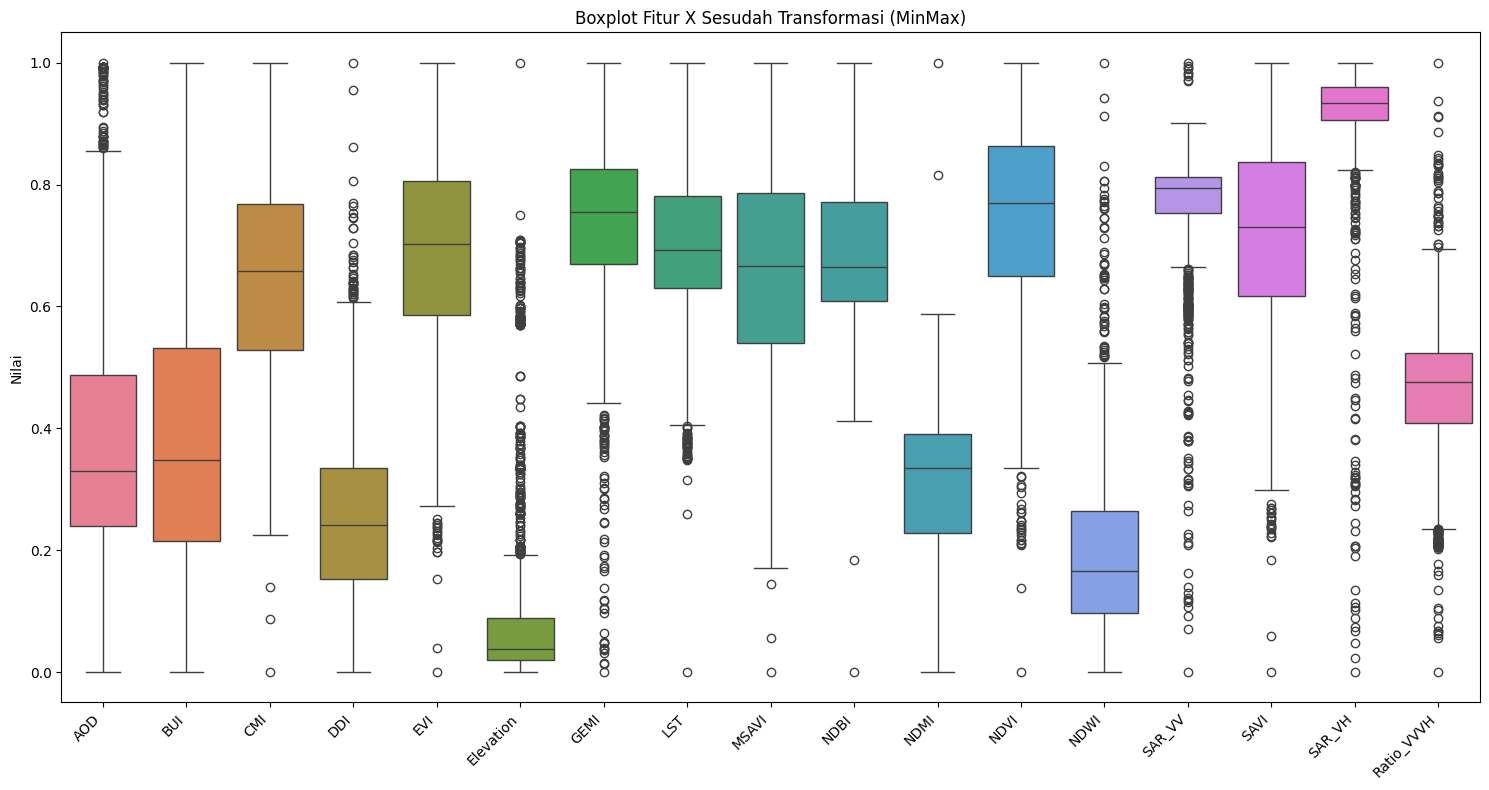

In [26]:
# prompt: boxplot data X sebelum dan sesudah transformasi

# Boxplot data X sebelum dan sesudah transformasi
features_to_plot = X_train_imputed.columns # Gunakan semua fitur atau pilih beberapa

# Sebelum Transformasi
plt.figure(figsize=(15, 8))
sns.boxplot(data=X_train_imputed[features_to_plot])
plt.title('Boxplot Fitur X Sebelum Transformasi (Setelah Imputasi)')
plt.ylabel('Nilai')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Sesudah Transformasi (MinMax)
plt.figure(figsize=(15, 8))
sns.boxplot(data=X_train[features_to_plot])
plt.title('Boxplot Fitur X Sesudah Transformasi (MinMax)')
plt.ylabel('Nilai')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [27]:
X_train

,AOD,BUI,CMI,DDI,EVI,Elevation,GEMI,LST,MSAVI,NDBI,NDMI,NDVI,NDWI,SAR_VV,SAVI,SAR_VH,Ratio_VVVH
0,0.443182,0.463686,0.583213,0.151871,0.626512,0.106587,0.700315,0.781064,0.577636,0.754075,0.245925,0.702478,0.216071,0.822268,0.657748,0.927567,0.569054
1,0.610140,0.139089,0.825774,0.197689,0.867667,0.080279,0.866224,0.556838,0.870065,0.585049,0.414951,0.922009,0.046490,0.821086,0.905466,0.971590,0.521756
2,0.336458,0.410663,0.614449,0.119416,0.654988,0.204996,0.729430,0.675316,0.628264,0.741788,0.258212,0.750473,0.165997,0.779639,0.707010,0.911792,0.563681
3,0.359578,0.345678,0.682393,0.179293,0.718115,0.292252,0.763195,0.665199,0.689243,0.697364,0.302636,0.787394,0.154378,0.821781,0.754562,0.962108,0.378680
4,0.507395,0.323723,0.683909,0.131825,0.730846,0.135818,0.756867,0.605733,0.663349,0.670110,0.329890,0.790775,0.173739,0.762693,0.735792,0.952783,0.622860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,0.214978,0.324171,0.644517,0.283231,0.696880,0.574767,0.763094,0.667151,0.683990,0.678014,0.321986,0.795320,0.124919,0.802042,0.751440,0.942162,0.588066
1971,0.756684,0.695655,0.409838,0.302456,0.484528,0.028709,0.620363,0.873832,0.425728,0.866690,0.133310,0.542804,0.319829,0.900907,0.505452,0.974768,0.211703
1972,0.720147,0.665726,0.412699,0.258981,0.467933,0.015381,0.546602,0.750782,0.429142,0.819303,0.180697,0.530486,0.359706,0.629281,0.506702,0.716805,0.646281
1973,0.265888,0.521717,0.617036,0.198587,0.663952,0.148457,0.776815,0.874773,0.620797,0.823571,0.176429,0.703018,0.192891,0.729151,0.690218,0.896150,0.565509


# Sequential Feature Selection (SFS)

In [28]:
# prompt: count na in X_train

print("Jumlah nilai null di X_train setelah imputasi dan transformasi:")
print(y_test.isnull().sum().sum())

Jumlah nilai null di X_train setelah imputasi dan transformasi:
0


### SFS

In [29]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector as SFS_sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Define models
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)
}

filename = 'MSD_SFS_smotetomek.xlsx'
results_df = pd.read_excel(filename) if os.path.exists(filename) else pd.DataFrame(
    columns=['Model', 'Method', 'n_features', 'Selected Features', 'Mean F1'])

n_features_list = list(range(1, 11))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Looping setiap model dan jumlah fitur
for model_name, model in models.items():
    print(f"\n✨ Model: {model_name}")

    for n_features in n_features_list:
        print(f"  🔹 Jumlah Fitur: {n_features}")

        for direction in ['forward', 'backward']:
            method_name = f"SFS-{direction.capitalize()}"

            exist = (
                (results_df['Model'] == model_name) &
                (results_df['Method'] == method_name) &
                (results_df['n_features'] == n_features)
            ).any()

            if not exist:
                selector = SFS_sklearn(model,
                                       n_features_to_select=n_features,
                                       direction=direction,
                                       cv=cv,
                                       n_jobs=-1,
                                       scoring='f1_macro')  # Ganti di sini
                selector.fit(X_train, y_train)
                selected = X_train.columns[selector.get_support()].tolist()

                scores = cross_val_score(model, X_train[selected], y_train, cv=cv, scoring='f1_macro')  # Ganti di sini
                mean_score = np.mean(scores)

                results_df = pd.concat([results_df, pd.DataFrame([{
                    'Model': model_name,
                    'Method': method_name,
                    'n_features': n_features,
                    'Selected Features': ', '.join(selected),
                    'Mean F1': mean_score  # Ganti nama kolom
                }])], ignore_index=True)
                results_df.to_excel(filename, index=False)
            else:
                print(f"    ✅ {method_name} untuk {n_features} fitur sudah ada, skip!")

print("\n✅ SEMUA SELESAI. Hasil tersimpan di 'MSD_SFS_smotetomek.xlsx'")



✨ Model: RandomForest
  🔹 Jumlah Fitur: 1
    ✅ SFS-Forward untuk 1 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 1 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 2
    ✅ SFS-Forward untuk 2 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 2 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 3
    ✅ SFS-Forward untuk 3 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 3 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 4
    ✅ SFS-Forward untuk 4 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 4 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 5
    ✅ SFS-Forward untuk 5 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 5 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 6
    ✅ SFS-Forward untuk 6 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 6 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 7
    ✅ SFS-Forward untuk 7 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 7 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 8
    ✅ SFS-Forward untuk 8 fitur sudah ada, skip!
    ✅ SFS-Backward untuk 8 fitur sudah ada, skip!
  🔹 Jumlah Fitur: 9
    ✅

### F1 tiap n_features

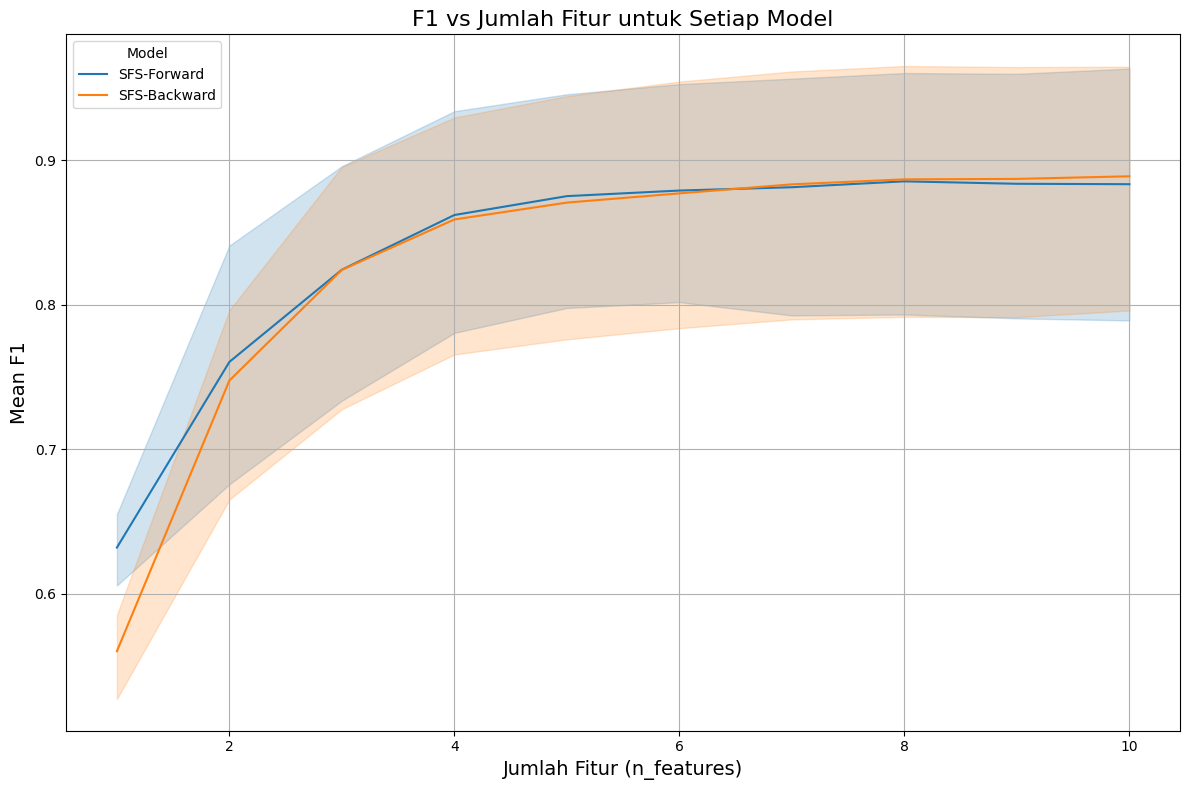

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
file_path = 'MSD_SFS_smotetomek.xlsx'
result_df = pd.read_excel(file_path, sheet_name='Sheet1')

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=result_df,
    x='n_features',
    y='Mean F1',
    hue='Method',     # Beda warna berdasarkan Model
    markers=True,
    dashes=False
)

plt.title('F1 vs Jumlah Fitur untuk Setiap Model', fontsize=16)
plt.xlabel('Jumlah Fitur (n_features)', fontsize=14)
plt.ylabel('Mean F1', fontsize=14)
plt.legend(title='Model')
plt.grid(True)
plt.tight_layout()
plt.show()


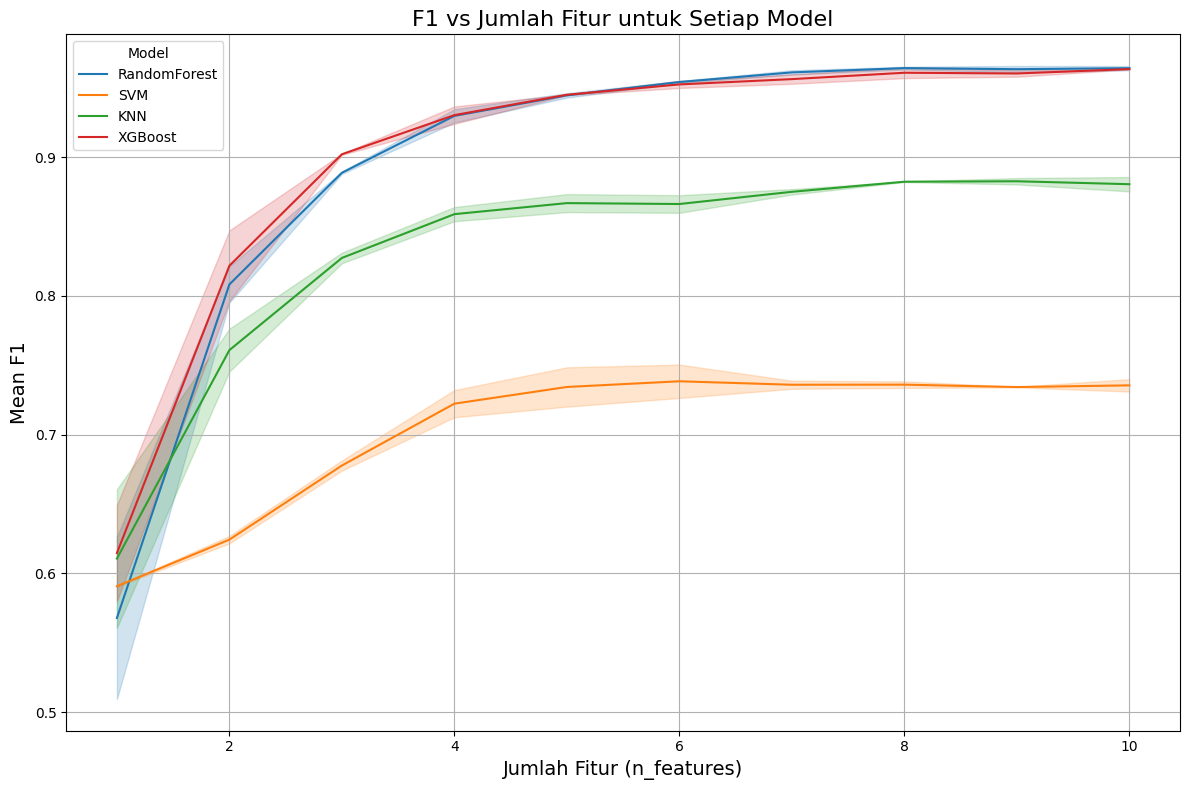

In [31]:
# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=result_df,
    x='n_features',
    y='Mean F1',
     hue='Model',
    markers=True,
    dashes=False

)

plt.title('F1 vs Jumlah Fitur untuk Setiap Model', fontsize=16)
plt.xlabel('Jumlah Fitur (n_features)', fontsize=14)
plt.ylabel('Mean F1', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

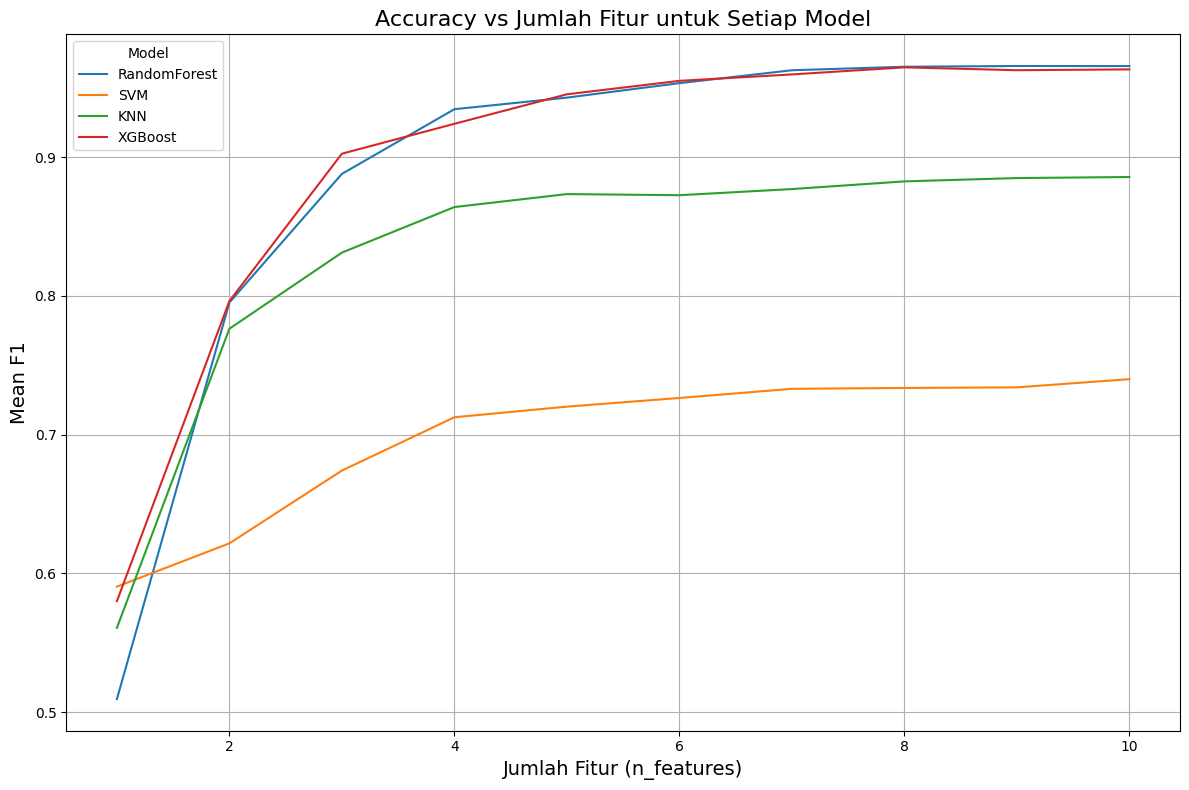

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter hanya metode backward
df_backward = result_df[result_df['Method'] == 'SFS-Backward']

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=df_backward,
    x='n_features',
    y='Mean F1',
    hue='Model',     # Beda warna berdasarkan Model
    markers=True,
    dashes=False
)

plt.title('Accuracy vs Jumlah Fitur untuk Setiap Model', fontsize=16)
plt.xlabel('Jumlah Fitur (n_features)', fontsize=14)
plt.ylabel('Mean F1', fontsize=14)
plt.legend(title='Model')
plt.grid(True)
plt.tight_layout()
plt.show()


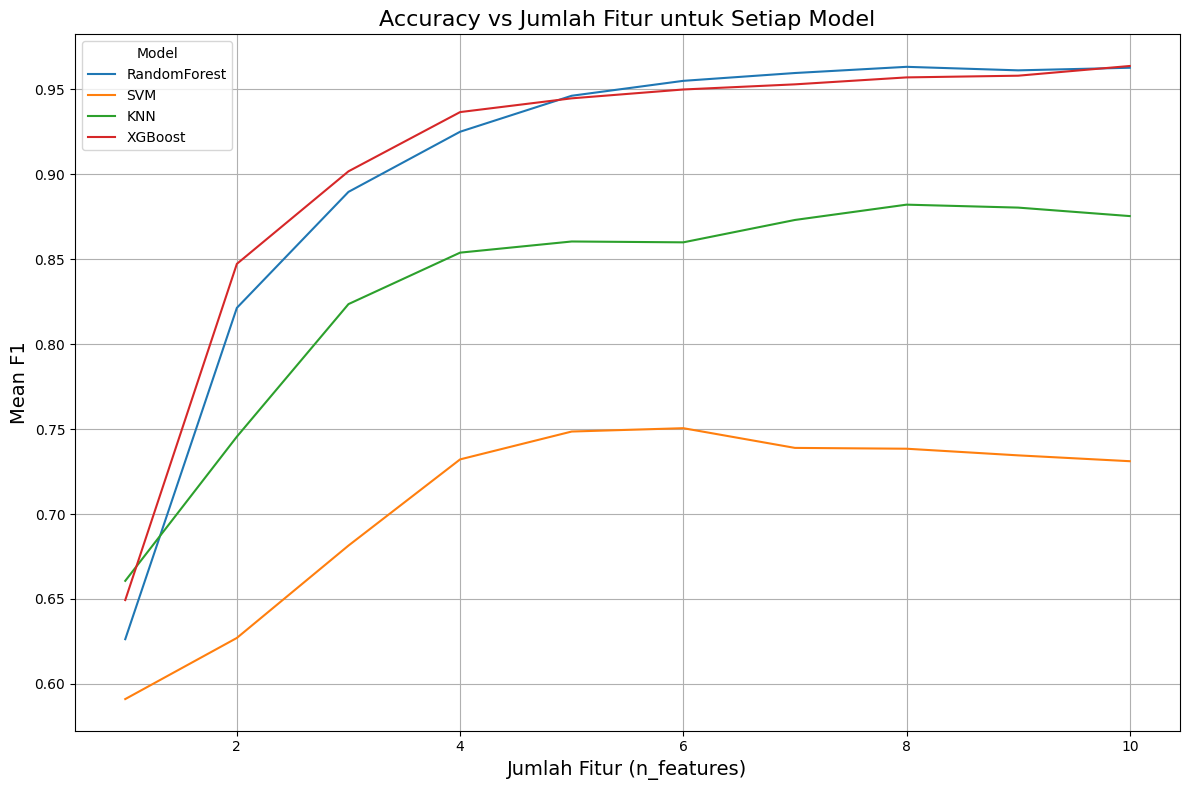

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter hanya metode backward
df_forward = result_df[result_df['Method'] == 'SFS-Forward']

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=df_forward,
    x='n_features',
    y='Mean F1',
    hue='Model',     # Beda warna berdasarkan Model
    markers=True,
    dashes=False
)

plt.title('Accuracy vs Jumlah Fitur untuk Setiap Model', fontsize=16)
plt.xlabel('Jumlah Fitur (n_features)', fontsize=14)
plt.ylabel('Mean F1', fontsize=14)
plt.legend(title='Model')
plt.grid(True)
plt.tight_layout()
plt.show()


### Fitur yang Paling Banyak Dipilih


📋 Majority Voting Table:

       Feature  Count
0          AOD     65
1         NDMI     51
2       SAR_VH     44
3          CMI     38
4   Ratio_VVVH     35
5          LST     33
6    Elevation     27
7          DDI     23
8         NDBI     22
9         NDWI     17
10      SAR_VV     16
11       MSAVI     14
12        NDVI     13
13        GEMI     13
14         BUI     11
15        SAVI     10
16         EVI      8


/tmp/ipykernel_2271/1341961869.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=majority_voting_df, x='Count', y='Feature', palette='viridis')


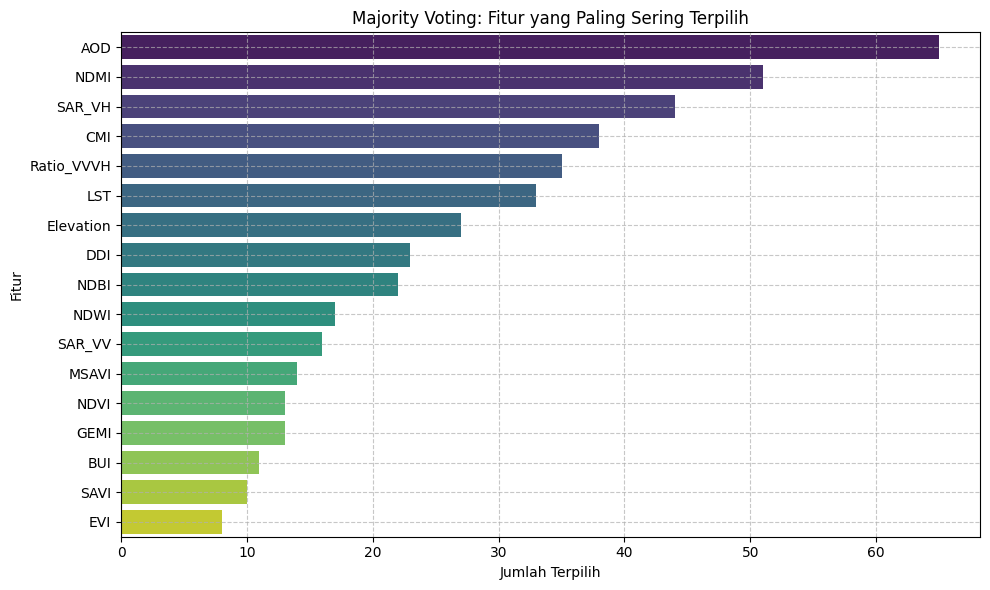


✅ Majority voting table disimpan di majority_voting_feature_selection.xlsx



In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Majority Voting: Hitung berapa kali tiap fitur dipilih ---
# Pisahin kolom 'Selected Features' jadi list
all_selected_features = []

for features_str in result_df['Selected Features']:
    features_list = [f.strip() for f in features_str.split(',')]
    all_selected_features.extend(features_list)

# Hitung frekuensi setiap fitur
feature_counts = pd.Series(all_selected_features).value_counts()

# Tampilkan tabel Majority Voting
majority_voting_df = feature_counts.reset_index()
majority_voting_df.columns = ['Feature', 'Count']
print("\n📋 Majority Voting Table:\n")
print(majority_voting_df)

# --- Visualisasi ---
plt.figure(figsize=(10, 6))
sns.barplot(data=majority_voting_df, x='Count', y='Feature', palette='viridis')
plt.title('Majority Voting: Fitur yang Paling Sering Terpilih')
plt.xlabel('Jumlah Terpilih')
plt.ylabel('Fitur')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# (Optional) Simpan majority voting table ke Excel juga
majority_voting_df.to_excel('majority_voting_feature_selection.xlsx', index=False)
print("\n✅ Majority voting table disimpan di majority_voting_feature_selection.xlsx\n")


## Looping Modelling Hasil SFS

In [35]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import ast

# === Load file hasil SFS ===
df_sfs = pd.read_excel("MSD_SFS_smotetomek.xlsx")

# === Filter hanya yang n_features = 3 ===
df_sfs_3 = df_sfs[df_sfs['n_features'] == 3].reset_index(drop=True)

# === Inisialisasi model-model ===
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# === Ganti ini dengan data kamu ===
# Misalnya sudah disiapkan dari sebelumnya
# X_train, X_test, y_train, y_test

all_results = []

for i, row in df_sfs_3.iterrows():
    # Ubah dari string ke list fitur
    selected_features = [feat.strip() for feat in row['Selected Features'].split(',')]

    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]

    for model_name, model in models.items():
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)

        result = {
            "Set ke-": i+1,
            "Model": model_name,
            "Features": ', '.join(selected_features),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
            "Recall (macro)": recall_score(y_test, y_pred, average='macro', zero_division=0),
            "F1 (macro)": f1_score(y_test, y_pred, average='macro', zero_division=0),
            "F1 (weighted)": f1_score(y_test, y_pred, average='weighted', zero_division=0)
        }
        all_results.append(result)


# === Tampilkan hasil dalam DataFrame ===
results_df = pd.DataFrame(all_results)
pd.set_option('display.max_columns', None)
print(results_df)

# === (Opsional) Simpan ke Excel ===
results_df.to_excel("evaluasi_model_n3.xlsx", index=False)


    Set ke-          Model               Features  Accuracy  \
0         1            KNN    MSAVI, NDMI, SAR_VH  0.608833   
1         1  Random Forest    MSAVI, NDMI, SAR_VH  0.772871   
2         1            SVM    MSAVI, NDMI, SAR_VH  0.413249   
3         1        XGBoost    MSAVI, NDMI, SAR_VH  0.785489   
4         2            KNN         AOD, DDI, NDWI  0.570978   
5         2  Random Forest         AOD, DDI, NDWI  0.722397   
6         2            SVM         AOD, DDI, NDWI  0.406940   
7         2        XGBoost         AOD, DDI, NDWI  0.738170   
8         3            KNN  AOD, NDMI, Ratio_VVVH  0.583596   
9         3  Random Forest  AOD, NDMI, Ratio_VVVH  0.716088   
10        3            SVM  AOD, NDMI, Ratio_VVVH  0.482650   
11        3        XGBoost  AOD, NDMI, Ratio_VVVH  0.725552   
12        4            KNN  AOD, NDBI, Ratio_VVVH  0.583596   
13        4  Random Forest  AOD, NDBI, Ratio_VVVH  0.703470   
14        4            SVM  AOD, NDBI, Ratio_VVVH  0.48

In [36]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import ast


# === Filter hanya yang n_features = 3 ===
df_sfs_5 = df_sfs[df_sfs['n_features'] == 4].reset_index(drop=True)

# === Inisialisasi model-model ===
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# === Ganti ini dengan data kamu ===
# Misalnya sudah disiapkan dari sebelumnya
# X_train, X_test, y_train, y_test

all_results = []

for i, row in df_sfs_5.iterrows():
    # Ubah dari string ke list fitur
    selected_features = [feat.strip() for feat in row['Selected Features'].split(',')]

    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]

    for model_name, model in models.items():
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)

        result = {
            "Set ke-": i+1,
            "Model": model_name,
            "Features": ', '.join(selected_features),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average='macro', zero_division=0),
            "Recall (macro)": recall_score(y_test, y_pred, average='macro', zero_division=0),
            "F1 (macro)": f1_score(y_test, y_pred, average='macro', zero_division=0),
            "F1 (weighted)": f1_score(y_test, y_pred, average='weighted', zero_division=0)
        }
        all_results.append(result)


# === Tampilkan hasil dalam DataFrame ===
results_df = pd.DataFrame(all_results)
pd.set_option('display.max_columns', None)
print(results_df)

# === (Opsional) Simpan ke Excel ===
results_df.to_excel("evaluasi_model_n5.xlsx", index=False)


    Set ke-          Model                      Features  Accuracy  \
0         1            KNN      AOD, MSAVI, NDMI, SAR_VH  0.586751   
1         1  Random Forest      AOD, MSAVI, NDMI, SAR_VH  0.785489   
2         1            SVM      AOD, MSAVI, NDMI, SAR_VH  0.507886   
3         1        XGBoost      AOD, MSAVI, NDMI, SAR_VH  0.801262   
4         2            KNN    AOD, DDI, NDWI, Ratio_VVVH  0.526814   
5         2  Random Forest    AOD, DDI, NDWI, Ratio_VVVH  0.738170   
6         2            SVM    AOD, DDI, NDWI, Ratio_VVVH  0.438486   
7         2        XGBoost    AOD, DDI, NDWI, Ratio_VVVH  0.738170   
8         3            KNN    AOD, DDI, NDMI, Ratio_VVVH  0.627760   
9         3  Random Forest    AOD, DDI, NDMI, Ratio_VVVH  0.772871   
10        3            SVM    AOD, DDI, NDMI, Ratio_VVVH  0.504732   
11        3        XGBoost    AOD, DDI, NDMI, Ratio_VVVH  0.785489   
12        4            KNN    AOD, CMI, NDBI, Ratio_VVVH  0.637224   
13        4  Random 

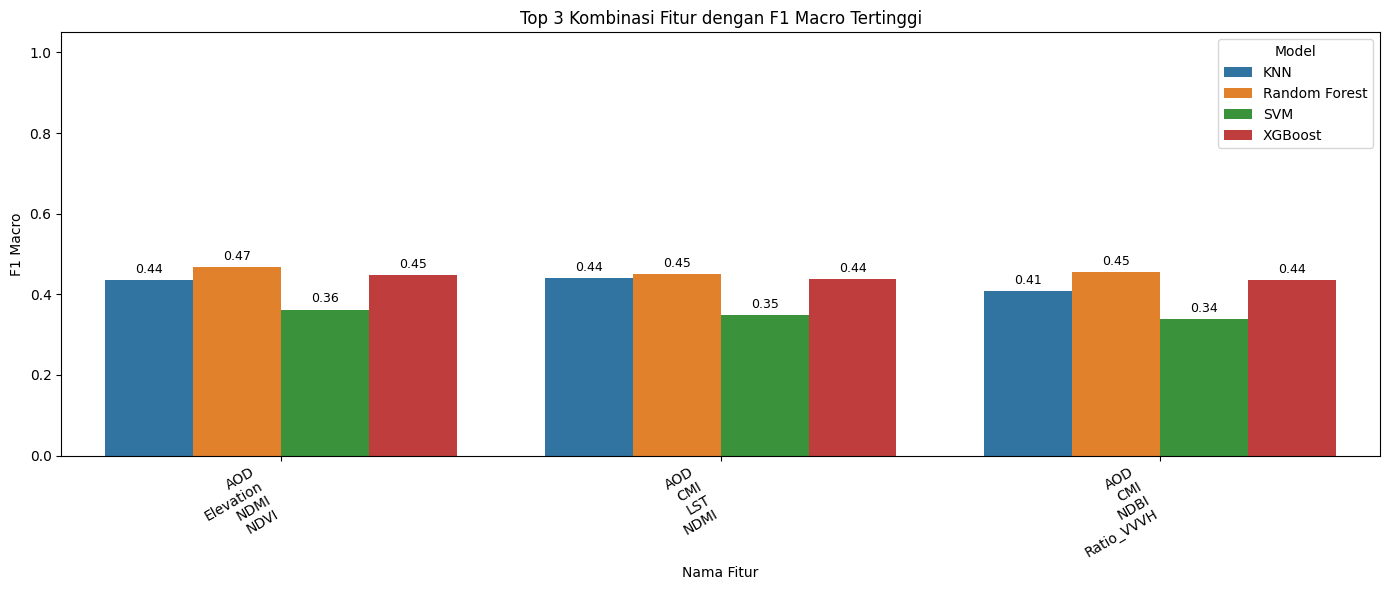

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gabungkan nama fitur dengan newline untuk label x (biar rapi)
results_df['Fitur Gabungan'] = results_df['Features'].apply(lambda x: '\n'.join(x.split(', ')))

# Ambil 5 kombinasi fitur unik terbaik berdasarkan F1 Macro
top5_features = (
    results_df
    .sort_values(by="F1 (macro)", ascending=False)
    .drop_duplicates(subset='Features')
    .head(3)
)['Features'].tolist()

# Filter semua baris yang memiliki kombinasi fitur di atas
top5_df = results_df[results_df['Features'].isin(top5_features)].copy()
top5_df['Fitur Gabungan'] = top5_df['Features'].apply(lambda x: '\n'.join(x.split(', ')))

# Urutkan kategori fitur gabungan berdasarkan rata-rata F1 tertinggi → paling tinggi di kiri
order_by_mean_f1 = (
    top5_df.groupby('Fitur Gabungan')['F1 (macro)']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Plot
plt.figure(figsize=(14, 6))
barplot = sns.barplot(
    data=top5_df,
    x="Fitur Gabungan",
    y="F1 (macro)",
    hue="Model",
    order=order_by_mean_f1
)

# Tambahkan label angka di atas bar
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9, padding=3)

plt.title("Top 3 Kombinasi Fitur dengan F1 Macro Tertinggi")
plt.ylabel("F1 Macro")
plt.xlabel("Nama Fitur")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha='right')
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# Modelling

## AOD, Elevation, NDMI, NDVI

### Training-Testing


Confusion Matrix with Totals - KNN
              Pred 0  Pred 1  Pred 2  Total (True)
True 0             3       7       1            11
True 1            70     192      12           274
True 2            10       9      13            32
Total (Pred)      83     208      26           317


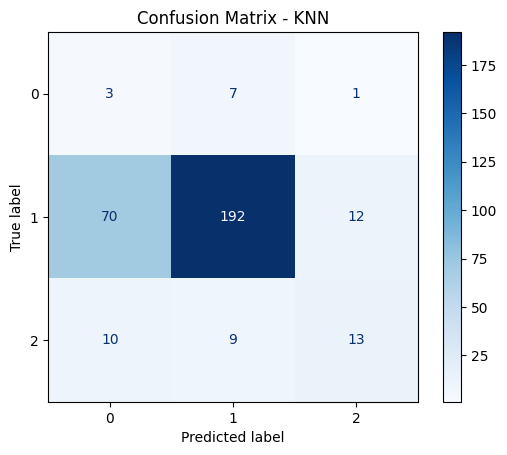


Confusion Matrix with Totals - RandomForest
              Pred 0  Pred 1  Pred 2  Total (True)
True 0             2       9       0            11
True 1            35     236       3           274
True 2             5      18       9            32
Total (Pred)      42     263      12           317


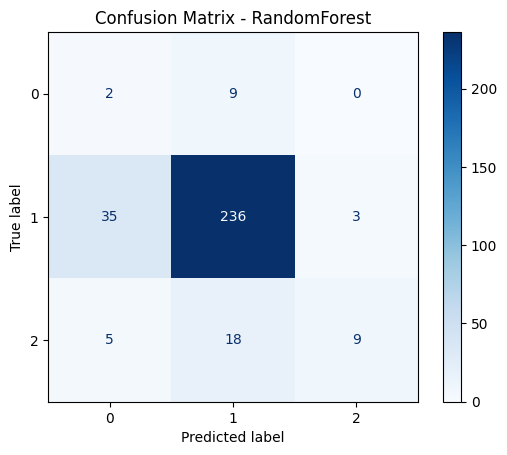


Confusion Matrix with Totals - XGBoost
              Pred 0  Pred 1  Pred 2  Total (True)
True 0             2       9       0            11
True 1            36     237       1           274
True 2             4      20       8            32
Total (Pred)      42     266       9           317


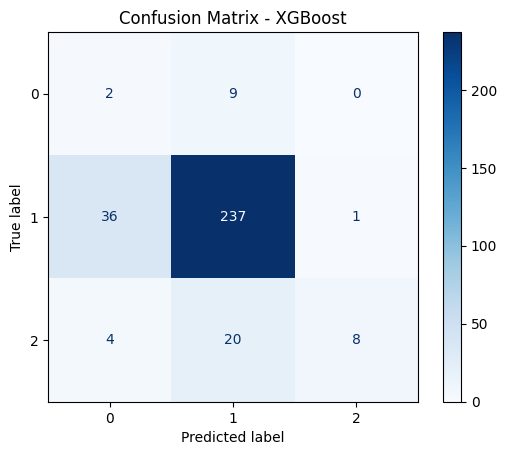


Confusion Matrix with Totals - SVM
              Pred 0  Pred 1  Pred 2  Total (True)
True 0             4       7       0            11
True 1           124     137      13           274
True 2            11      10      11            32
Total (Pred)     139     154      24           317


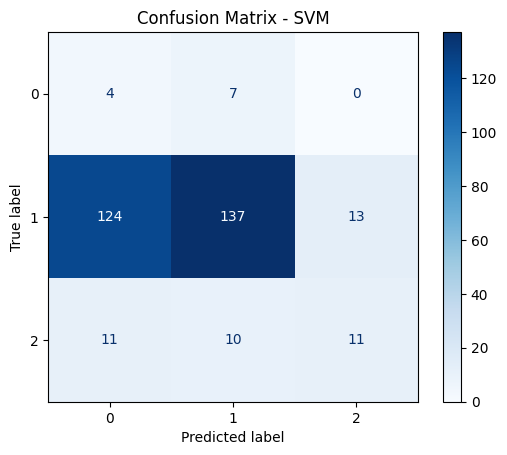

          Model  Train Accuracy  Train F1 Macro  Train F1 Weighted  \
0           KNN        0.912405        0.909497           0.909518   
1  RandomForest        1.000000        1.000000           1.000000   
2       XGBoost        1.000000        1.000000           1.000000   
3           SVM        0.655696        0.651788           0.651800   

   Train Precision Macro  Train Precision Weighted  Train Recall Macro  \
0               0.921040                  0.921036            0.912365   
1               1.000000                  1.000000            1.000000   
2               1.000000                  1.000000            1.000000   
3               0.702024                  0.702128            0.655755   

   Train Recall Weighted  Test Accuracy  Test F1 Macro  Test F1 Weighted  \
0               0.912405       0.656151       0.436262          0.736080   
1               1.000000       0.779180       0.454507          0.803645   
2               1.000000       0.779180       0.44

In [38]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# Fitur yang dipakai semua model
selected_features = ['AOD', 'Elevation', 'NDVI', 'NDMI']

# Daftar model (semua pakai fitur yang sama)
model_info = [
    {'model_name': 'KNN', 'model': KNeighborsClassifier()},
    {'model_name': 'RandomForest', 'model': RandomForestClassifier(random_state=42)},
    {'model_name': 'XGBoost', 'model': XGBClassifier(eval_metric='mlogloss', random_state=42)},
    {'model_name': 'SVM', 'model': SVC(probability=True, random_state=42)}
]

# Simpan hasil evaluasi
results = []

# Subset fitur yang sama untuk semua model
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

for info in model_info:
    name = info['model_name']
    model = info['model']

    # Training dengan data hasil SMOTE
    model.fit(X_train_sel, y_train)

    # Prediksi
    y_pred_train = model.predict(X_train_sel)
    y_pred_test = model.predict(X_test_sel)

    from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
    )
    import matplotlib.pyplot as plt

    # === Evaluasi Training
    train_acc = accuracy_score(y_train, y_pred_train)

    train_f1_macro = f1_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_f1_weighted = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)

    train_precision_macro = precision_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_precision_weighted = precision_score(y_train, y_pred_train, average='weighted', zero_division=0)

    train_recall_macro = recall_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_recall_weighted = recall_score(y_train, y_pred_train, average='weighted', zero_division=0)

    # === Evaluasi Testing
    test_acc = accuracy_score(y_test, y_pred_test)

    test_f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_f1_weighted = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

    test_precision_macro = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_precision_weighted = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)

    test_recall_macro = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_recall_weighted = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)

    # === Simpan ke hasil
    results.append({
        'Model': name,

        'Train Accuracy': train_acc,
        'Train F1 Macro': train_f1_macro,
        'Train F1 Weighted': train_f1_weighted,
        'Train Precision Macro': train_precision_macro,
        'Train Precision Weighted': train_precision_weighted,
        'Train Recall Macro': train_recall_macro,
        'Train Recall Weighted': train_recall_weighted,

        'Test Accuracy': test_acc,
        'Test F1 Macro': test_f1_macro,
        'Test F1 Weighted': test_f1_weighted,
        'Test Precision Macro': test_precision_macro,
        'Test Precision Weighted': test_precision_weighted,
        'Test Recall Macro': test_recall_macro,
        'Test Recall Weighted': test_recall_weighted
    })


    # Hitung confusion matrix
    cm = confusion_matrix(y_test, y_pred_test)
    labels = sorted(np.unique(y_test))  # pastikan urutan label benar

    # Buat DataFrame untuk tampilan tabel + total
    cm_df = pd.DataFrame(cm, index=[f"True {label}" for label in labels],
                            columns=[f"Pred {label}" for label in labels])

    # Tambahkan total per baris dan kolom
    cm_df["Total (True)"] = cm_df.sum(axis=1)
    total_col = cm_df.sum(axis=0)
    total_col.name = "Total (Pred)"
    cm_df = pd.concat([cm_df, total_col.to_frame().T])

    # Tampilkan sebagai tabel
    print(f"\nConfusion Matrix with Totals - {name}")
    print(cm_df)

    # Plot visual seperti biasa
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()



# Tampilkan hasil
results_df = pd.DataFrame(results)
print(results_df)

# Simpan ke Excel (opsional)
results_df.to_excel("Final_Eval_SameFeatures_SMOTE.xlsx", index=False)


### Optuna

#### Random Forest

In [39]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Pilih fitur hasil seleksi RandomForest
X_sel = X_train[selected_features]

def objective(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 180, 300),  # naik dikit
        max_depth=trial.suggest_int("max_depth", 15, 25),  # biar bisa pohon lebih dalam
        min_samples_split=trial.suggest_int("min_samples_split", 4, 8),  # turunin dikit = pohon lebih bercabang
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 2, 5),  # lebih kecil = leaf boleh lebih detail
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 40, 70),  # bisa bikin pohon lebih rimbun
        ccp_alpha=trial.suggest_float("ccp_alpha", 0.0005, 0.005),  # pruning-nya dikendurin dikit
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )


    try:
        # Gunakan cross-validation langsung tanpa pipeline SMOTE
        score = cross_val_score(model, X_sel, y_train, cv=5, scoring='f1_macro', error_score='raise').mean()
    except ValueError as e:
        return 0.0

    return score

# Buat studi Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Simpan hasil terbaik
best_params_randomforest = study.best_params
print("✅ Best F1 RF:", study.best_value)
print("🔧 Best Params RF:", best_params_randomforest)


[I 2026-07-16 02:07:26,172] A new study created in memory with name: no-name-bf98e680-59d9-4f42-bb2b-6edf3791ce6e
[I 2026-07-16 02:07:32,775] Trial 0 finished with value: 0.8823120409152077 and parameters: {'n_estimators': 284, 'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_leaf_nodes': 64, 'ccp_alpha': 0.002680488775902564}. Best is trial 0 with value: 0.8823120409152077.
[I 2026-07-16 02:07:38,798] Trial 1 finished with value: 0.8915703802782836 and parameters: {'n_estimators': 245, 'max_depth': 25, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_leaf_nodes': 68, 'ccp_alpha': 0.0023805443247225822}. Best is trial 1 with value: 0.8915703802782836.
[I 2026-07-16 02:07:44,820] Trial 2 finished with value: 0.8594043912547029 and parameters: {'n_estimators': 257, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_leaf_nodes': 48, 'ccp_alpha': 0.003938437119059528}. Best is t

✅ Best F1 RF: 0.9080669581221125
🔧 Best Params RF: {'n_estimators': 213, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_leaf_nodes': 70, 'ccp_alpha': 0.0005034444828223445}


#### XGBoost

In [40]:
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# Fitur yang digunakan
X_sel = X_train[selected_features]
def objective(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 80, 150),         # jumlah pohon moderat
        max_depth=trial.suggest_int("max_depth", 3, 4),                  # cetek tapi cukup fleksibel
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.1),   # kecil stabil
        subsample=trial.suggest_float("subsample", 0.7, 0.9),            # biar generalisasi lebih baik
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 0.9), # sampling fitur sedang
        gamma=trial.suggest_float("gamma", 1.0, 3.0),                    # cegah split sembarangan
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )


    try:
        # Tanpa SMOTE, langsung evaluasi model
        score = cross_val_score(model, X_sel.values, y_train.values, cv=5, scoring='f1_macro', error_score='raise').mean()
    except ValueError:
        return 0.0

    return score

# Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Output hasil terbaik
best_params_xgboost = study.best_params
print("✅ Best F1 XGB:", study.best_value)
print("🔧 Best Params XGB:", best_params_xgboost)


[I 2026-07-16 02:16:22,134] A new study created in memory with name: no-name-f26644a1-abaf-4daf-97de-1f6499eece02
[I 2026-07-16 02:16:22,723] Trial 0 finished with value: 0.7893149024582244 and parameters: {'n_estimators': 104, 'max_depth': 3, 'learning_rate': 0.07076707232234737, 'subsample': 0.831379977981803, 'colsample_bytree': 0.7968565180217991, 'gamma': 2.9833828998011787}. Best is trial 0 with value: 0.7893149024582244.
[I 2026-07-16 02:16:23,283] Trial 1 finished with value: 0.8050090754870318 and parameters: {'n_estimators': 86, 'max_depth': 3, 'learning_rate': 0.05942703398114839, 'subsample': 0.8549421728927634, 'colsample_bytree': 0.8516713102037021, 'gamma': 1.9626501856844631}. Best is trial 1 with value: 0.8050090754870318.
[I 2026-07-16 02:16:23,800] Trial 2 finished with value: 0.8260289931330241 and parameters: {'n_estimators': 85, 'max_depth': 4, 'learning_rate': 0.07832567865347925, 'subsample': 0.7009524380101207, 'colsample_bytree': 0.7000289559758178, 'gamma': 1

✅ Best F1 XGB: 0.8787394837701863
🔧 Best Params XGB: {'n_estimators': 142, 'max_depth': 4, 'learning_rate': 0.09665495968816143, 'subsample': 0.7733893404401119, 'colsample_bytree': 0.7977286988066691, 'gamma': 1.0265542871180646}


#### KNN

In [41]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Fitur yang dipilih
X_sel = X_train[selected_features]

def objective(trial):
    model = KNeighborsClassifier(
        n_neighbors = trial.suggest_int('n_neighbors', 3, 30),  # perbesar jarak
        weights = trial.suggest_categorical('weights', ['uniform']),  # hindari 'distance'
        metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan'])
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    try:
        score = cross_val_score(
            pipeline,
            X_sel.values,
            y_train.values,
            cv=5,
            scoring='f1_macro',
            error_score='raise'
        ).mean()
    except ValueError:
        return 0.0

    return score

# Optuna tuning
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params_knn = study.best_params
print("✅ Best F1 KNN:", study.best_value)
print("🔧 Best Params KNN:", best_params_knn)


[I 2026-07-16 02:18:01,010] A new study created in memory with name: no-name-adc37638-a88d-4887-9814-e47973a30431
[I 2026-07-16 02:18:01,086] Trial 0 finished with value: 0.7934026704204982 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.7934026704204982.
[I 2026-07-16 02:18:01,164] Trial 1 finished with value: 0.785307644609814 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.7934026704204982.
[I 2026-07-16 02:18:01,238] Trial 2 finished with value: 0.7961755418419736 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 2 with value: 0.7961755418419736.
[I 2026-07-16 02:18:01,301] Trial 3 finished with value: 0.8124137100866344 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 3 with value: 0.8124137100866344.
[I 2026-07-16 02:18:01,374] Trial 4 finished with value: 0.7869

✅ Best F1 KNN: 0.893972339812748
🔧 Best Params KNN: {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'}


#### SVM

In [42]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Fitur input
X_sel = X_train[selected_features]

def objective(trial):
    model = SVC(
        C = trial.suggest_float('C', 50, 150, log=True),         # Range lebih tinggi
        gamma = trial.suggest_float('gamma', 0.2, 0.4, log=True),  # Biarkan lebih sensitif
        kernel = trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"]),  # biar eksplor lebih jauh
        degree = 3  # default untuk 'poly'
    )

    from sklearn.preprocessing import StandardScaler

    pipeline = Pipeline([
        ('scaler', StandardScaler()),  # Scaling before SVM
        ('classifier', model)
    ])


    try:
        score = cross_val_score(
            pipeline,
            X_sel.values,
            y_train.values,
            cv=5,
            scoring='f1_macro',
            error_score='raise'
        ).mean()
    except ValueError:
        return 0.0

    return score

# Optuna tuning
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

best_params_svm = study.best_params
print("✅ Best F1 SVM:", study.best_value)
print("🔧 Best Params SVM:", best_params_svm)


[I 2026-07-16 02:18:07,469] A new study created in memory with name: no-name-8583fa32-dcea-4aba-908b-f706203acc9b
[I 2026-07-16 02:18:08,517] Trial 0 finished with value: 0.8230357991072033 and parameters: {'C': 100.69917757387941, 'gamma': 0.21859738169795973, 'kernel': 'rbf'}. Best is trial 0 with value: 0.8230357991072033.
[I 2026-07-16 02:18:09,502] Trial 1 finished with value: 0.8396233426255403 and parameters: {'C': 67.81831176362262, 'gamma': 0.3139340854795706, 'kernel': 'rbf'}. Best is trial 1 with value: 0.8396233426255403.
[I 2026-07-16 02:18:11,906] Trial 2 finished with value: 0.6653644994231717 and parameters: {'C': 75.41103936910972, 'gamma': 0.2375933269761662, 'kernel': 'poly'}. Best is trial 1 with value: 0.8396233426255403.
[I 2026-07-16 02:18:12,651] Trial 3 finished with value: 0.27293445240309533 and parameters: {'C': 64.36547201975311, 'gamma': 0.2332811704120765, 'kernel': 'sigmoid'}. Best is trial 1 with value: 0.8396233426255403.
[I 2026-07-16 02:18:18,119] Tr

✅ Best F1 SVM: 0.8801060198103421
🔧 Best Params SVM: {'C': 146.0342162490093, 'gamma': 0.38175740338358577, 'kernel': 'rbf'}


### Final Training


🌟 Final Training: KNN


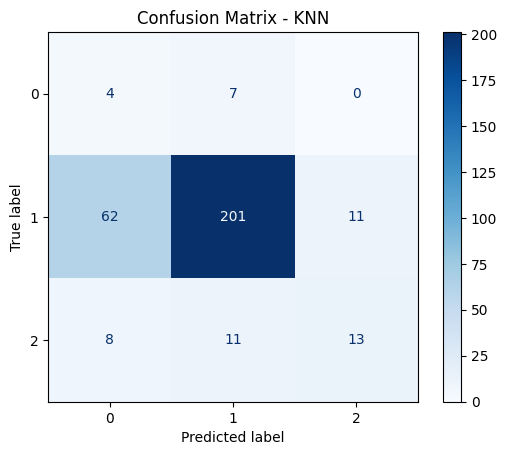


🌟 Final Training: RandomForest


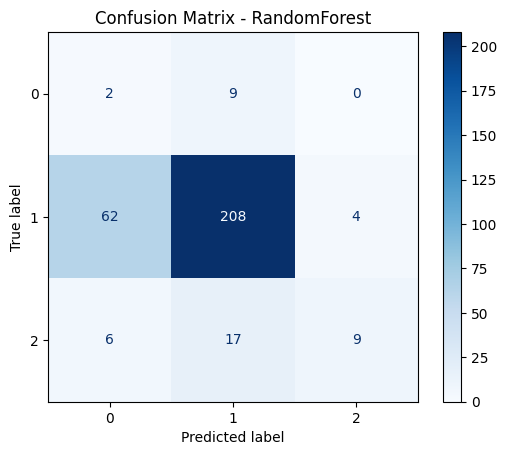


🌟 Final Training: XGBoost


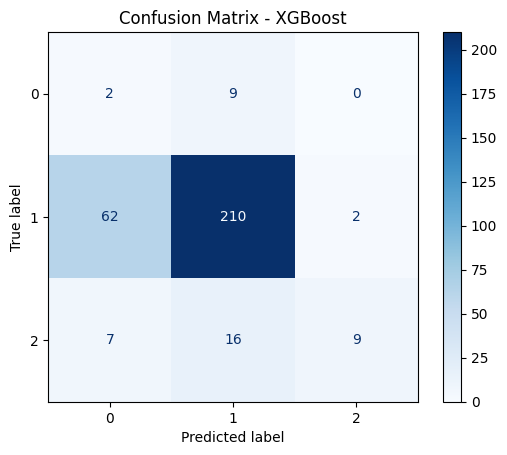


🌟 Final Training: SVM


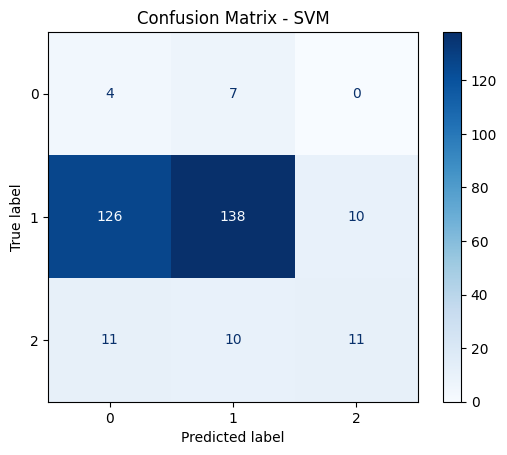


📊 Final Evaluation Result (Same Features):
          Model  Train Accuracy  Train F1 Macro  Train F1 Weighted  \
0           KNN        0.937215        0.935872           0.935885   
1  RandomForest        0.956456        0.956281           0.956294   
2       XGBoost        0.932658        0.932163           0.932178   
3           SVM        0.656203        0.652600           0.652610   

   Train Precision Macro  Train Precision Weighted  Train Recall Macro  \
0               0.941431                  0.941426            0.937186   
1               0.958722                  0.958732            0.956440   
2               0.935208                  0.935218            0.932639   
3               0.697314                  0.697412            0.656261   

   Train Recall Weighted  Train Balanced Accuracy  Test Accuracy  \
0               0.937215                 0.937186       0.687697   
1               0.956456                 0.956440       0.690852   
2               0.932658      

In [43]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt

# === Best Params dari hasil tuning ===
best_params_knn =  {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'}
best_params_randomforest = {'n_estimators': 260, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_leaf_nodes': 70, 'ccp_alpha': 0.0007494603784018026}
best_params_xgboost =  {'n_estimators': 126, 'max_depth': 4, 'learning_rate': 0.09772884006489047, 'subsample': 0.873125509598161, 'colsample_bytree': 0.7749603405678034, 'gamma': 1.004011576034406}
best_params_svm =  {'C': 149.90337696665327, 'gamma': 0.3997859856573327, 'kernel': 'rbf'}

# Fitur yang disamakan untuk semua model
shared_features =  ['AOD', 'Elevation', 'NDVI', 'NDMI']

# Daftar model + best_params dari Optuna
model_info = [
    {
        'model_name': 'KNN',
        'model_class': KNeighborsClassifier,
        'best_params': best_params_knn
    },
    {
        'model_name': 'RandomForest',
        'model_class': RandomForestClassifier,
        'best_params': best_params_randomforest
    },
    {
        'model_name': 'XGBoost',
        'model_class': XGBClassifier,
        'best_params': best_params_xgboost
    },
    {
        'model_name': 'SVM',
        'model_class': SVC,
        'best_params': best_params_svm
    }
]

# Hasil akhir disimpan di sini
final_results = []

# Loop model
for info in model_info:
    name = info['model_name']
    model_class = info['model_class']
    params = info['best_params'].copy()

    print(f"\n🌟 Final Training: {name}")

    # Tambahkan random_state kalau belum ada (untuk reproducibility)
    if 'random_state' not in params and model_class not in [KNeighborsClassifier, SVC]:
        params['random_state'] = 42

    # Ambil fitur
    X_train_sel = X_train[shared_features]
    X_test_sel = X_test[shared_features]

    # Inisialisasi dan training
    model = model_class(**params)
    model.fit(X_train_sel, y_train)

    # Prediksi
    y_pred_train = model.predict(X_train_sel)
    y_pred_test = model.predict(X_test_sel)

    # === Evaluasi Training
    train_acc = accuracy_score(y_train, y_pred_train)
    train_f1_macro = f1_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_f1_weighted = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
    train_precision_macro = precision_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_precision_weighted = precision_score(y_train, y_pred_train, average='weighted', zero_division=0)
    train_recall_macro = recall_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_recall_weighted = recall_score(y_train, y_pred_train, average='weighted', zero_division=0)
    train_balanced_acc = balanced_accuracy_score(y_train, y_pred_train)

    # === Evaluasi Testing
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_f1_weighted = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
    test_precision_macro = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_precision_weighted = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    test_recall_macro = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
    test_recall_weighted = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
    test_balanced_acc = balanced_accuracy_score(y_test, y_pred_test)

    # Simpan hasil evaluasi
    final_results.append({
        'Model': name,

        'Train Accuracy': train_acc,
        'Train F1 Macro': train_f1_macro,
        'Train F1 Weighted': train_f1_weighted,
        'Train Precision Macro': train_precision_macro,
        'Train Precision Weighted': train_precision_weighted,
        'Train Recall Macro': train_recall_macro,
        'Train Recall Weighted': train_recall_weighted,
        'Train Balanced Accuracy': train_balanced_acc,

        'Test Accuracy': test_acc,
        'Test F1 Macro': test_f1_macro,
        'Test F1 Weighted': test_f1_weighted,
        'Test Precision Macro': test_precision_macro,
        'Test Precision Weighted': test_precision_weighted,
        'Test Recall Macro': test_recall_macro,
        'Test Recall Weighted': test_recall_weighted,
        'Test Balanced Accuracy': test_balanced_acc
    })

    # === Tampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# Buat DataFrame hasil
final_df = pd.DataFrame(final_results)

# Cetak dan simpan
print("\n📊 Final Evaluation Result (Same Features):")
print(final_df)

final_df.to_excel("Final_Evaluation_SameFeatures_OptunaTuned.xlsx", index=False)


# Cobain Ensemble

## Looping Voting Ensemble

In [44]:
import pandas as pd
from itertools import combinations
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Import model-model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# === Best Params dari hasil tuning ===
best_params_knn =  {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'}
best_params_randomforest = {'n_estimators': 260, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_leaf_nodes': 70, 'ccp_alpha': 0.0007494603784018026}
best_params_xgboost =  {'n_estimators': 126, 'max_depth': 4, 'learning_rate': 0.09772884006489047, 'subsample': 0.873125509598161, 'colsample_bytree': 0.7749603405678034, 'gamma': 1.004011576034406}
best_params_svm =  {'C': 149.90337696665327, 'gamma': 0.3997859856573327, 'kernel': 'rbf'}


# === Mapping nama model ke objek ===
model_info = {
    'KNN': KNeighborsClassifier(**best_params_knn),
    'RF': RandomForestClassifier(**best_params_randomforest, random_state=42),
    'XGB': XGBClassifier(**best_params_xgboost, eval_metric='logloss', random_state=42),
    'SVM': SVC(**best_params_svm, probability=True, random_state=42)
}


# Simulasi data dummy (hapus kalau pakai data asli)
import numpy as np
from sklearn.model_selection import train_test_split

shared_features = ['AOD', 'Elevation', 'NDMI', 'NDVI']

# === Loop kombinasi model 2–4 ===
results = []
for r in range(2, len(model_info)+1):
    for subset in combinations(model_info.items(), r):
        combo_name = '+'.join([name for name, _ in subset])
        estimators = list(subset)

        # Pipeline: scaler + soft voting
        ensemble = Pipeline([
            ('scaler', StandardScaler()),
            ('voting', VotingClassifier(estimators=estimators, voting='soft'))
        ])

        ensemble.fit(X_train[shared_features], y_train)
        y_pred = ensemble.predict(X_test[shared_features])

        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        acc = ensemble.score(X_test[shared_features], y_test)

        results.append({
            'Kombinasi Model': combo_name,
            'Jumlah Model': r,
            'F1 Score Macro': f1_macro,
            'F1 Score Weighted': f1_weighted,
            'Accuracy': acc
        })

# === Konversi ke DataFrame dan tampilkan
ensemble_df = pd.DataFrame(results).sort_values(by='F1 Score Macro', ascending=False)

# === Simpan ke Excel
ensemble_df.to_excel('ensemble_results.xlsx', index=False)

# === Tampilkan di output
print("📊 Top 10 Kombinasi Ensemble Berdasarkan F1 Score:")
print(ensemble_df.head(10))


📊 Top 10 Kombinasi Ensemble Berdasarkan F1 Score:
   Kombinasi Model  Jumlah Model  F1 Score Macro  F1 Score Weighted  Accuracy
0           KNN+RF             2        0.461745           0.771709  0.716088
1          KNN+XGB             2        0.453255           0.771228  0.719243
6       KNN+RF+XGB             3        0.452110           0.773164  0.722397
9       RF+XGB+SVM             3        0.451404           0.774206  0.728707
3           RF+XGB             2        0.440043           0.760037  0.703470
10  KNN+RF+XGB+SVM             4        0.439641           0.765515  0.719243
7       KNN+RF+SVM             3        0.437354           0.772385  0.731861
8      KNN+XGB+SVM             3        0.436161           0.770417  0.728707
2          KNN+SVM             2        0.420044           0.763618  0.719243
5          XGB+SVM             2        0.346863           0.740315  0.719243


## Looping Stacking Ensemble

In [45]:
import pandas as pd
from itertools import combinations
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import numpy as np

# === Import model ===
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# === Best params (from tuning) ===
best_params_knn =  {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'}
best_params_randomforest = {'n_estimators': 260, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_leaf_nodes': 70, 'ccp_alpha': 0.0007494603784018026}
best_params_xgboost =  {'n_estimators': 126, 'max_depth': 4, 'learning_rate': 0.09772884006489047, 'subsample': 0.873125509598161, 'colsample_bytree': 0.7749603405678034, 'gamma': 1.004011576034406}
best_params_svm =  {'C': 149.90337696665327, 'gamma': 0.3997859856573327, 'kernel': 'rbf'}


# === Inisialisasi model ===
all_models = {
    'KNN': KNeighborsClassifier(**best_params_knn),
    'RF': RandomForestClassifier(**best_params_randomforest, random_state=42),
    'XGB': XGBClassifier(**best_params_xgboost, eval_metric='logloss', random_state=42),
    'SVM': SVC(**best_params_svm, random_state=42)
}

shared_features = ['AOD', 'Elevation', 'NDMI', 'NDVI']

# === Loop kombinasi base model (ukuran 2 dan 3), sisanya sebagai meta-model ===
results = []

model_names = list(all_models.keys())

for r in [2, 3]:
    for base_names in combinations(model_names, r):
        meta_candidates = list(set(model_names) - set(base_names))

        meta_name = meta_candidates[0]
        base_models = [(name, all_models[name]) for name in base_names]
        meta_model = all_models[meta_name]

        # Buat pipeline stacking
        stacking = Pipeline([
            ('scaler', StandardScaler()),
            ('stacking', StackingClassifier(
                estimators=base_models,
                final_estimator=meta_model,
                passthrough=True,
                cv=5,
                n_jobs=-1
            ))
        ])

        stacking.fit(X_train[shared_features], y_train)
        y_pred = stacking.predict(X_test[shared_features])

        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        acc = stacking.score(X_test[shared_features], y_test)

        results.append({
            'Base Models': '+'.join(base_names),
            'Meta Model': meta_name,
            'Jumlah Base': len(base_names),
            'F1 Score Macro': f1_macro,
            'F1 Score Weighted': f1_weighted,
            'Accuracy': acc
        })

# Tampilkan hasil
stacking_df = pd.DataFrame(results).sort_values(by='F1 Score Macro', ascending=False)
stacking_df.to_excel("stacking_base2-3_meta1.xlsx", index=False)

print("📊 Top Kombinasi Base (2–3) + Meta Model:")
print(stacking_df.head(10))


📊 Top Kombinasi Base (2–3) + Meta Model:
   Base Models Meta Model  Jumlah Base  F1 Score Macro  F1 Score Weighted  \
1      KNN+XGB         RF            2        0.489969           0.823011   
0       KNN+RF        XGB            2        0.465562           0.810495   
7   KNN+RF+SVM        XGB            3        0.442424           0.805076   
9   RF+XGB+SVM        KNN            3        0.435936           0.791348   
4       RF+SVM        XGB            2        0.421586           0.791930   
3       RF+XGB        SVM            2        0.382014           0.774773   
6   KNN+RF+XGB        SVM            3        0.375644           0.778402   
2      KNN+SVM        XGB            2        0.373653           0.777473   
8  KNN+XGB+SVM         RF            3        0.363894           0.780929   
5      XGB+SVM         RF            2        0.349198           0.758983   

   Accuracy  
1  0.807571  
0  0.798107  
7  0.801262  
9  0.769716  
4  0.779180  
3  0.776025  
6  0.785489  

# Final

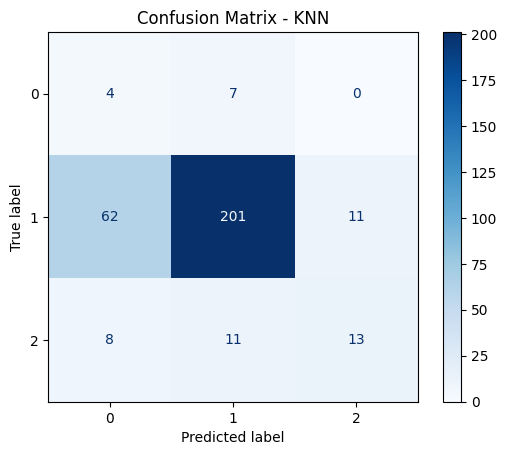


📊 Final Evaluation Result (KNN Only):
  Model  Train F1 Macro  Train F1 Weighted  Train Balanced Accuracy  \
0   KNN        0.935872           0.935885                 0.937186   

   Test F1 Macro  Test F1 Weighted  Test Balanced Accuracy  
0        0.45794          0.754941                0.501154  


In [46]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score
)
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import matplotlib.pyplot as plt

# === Best Params dari hasil tuning Optuna ===
best_params_knn = {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'}

# Fitur yang digunakan
shared_features = ['AOD', 'Elevation', 'NDVI', 'NDMI']
X_train_sel = X_train[shared_features]
X_test_sel = X_test[shared_features]

# Inisialisasi dan training model
model = KNeighborsClassifier(**best_params_knn)
model.fit(X_train_sel, y_train)

# Prediksi
y_pred_train = model.predict(X_train_sel)
y_pred_test = model.predict(X_test_sel)

# Evaluasi Training
train_f1_macro = f1_score(y_train, y_pred_train, average='macro', zero_division=0)
train_f1_weighted = f1_score(y_train, y_pred_train, average='weighted', zero_division=0)
train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)

# Evaluasi Testing
test_f1_macro = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
test_f1_weighted = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

# Simpan hasil ke DataFrame
final_results = pd.DataFrame([{
    'Model': 'KNN',
    'Train F1 Macro': train_f1_macro,
    'Train F1 Weighted': train_f1_weighted,
    'Train Balanced Accuracy': train_bal_acc,
    'Test F1 Macro': test_f1_macro,
    'Test F1 Weighted': test_f1_weighted,
    'Test Balanced Accuracy': test_bal_acc
}])

# Tampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - KNN")
plt.show()

# Print dan Simpan
print("\n📊 Final Evaluation Result (KNN Only):")
print(final_results)
final_results.to_excel("Final_KNN_Evaluation.xlsx", index=False)


In [47]:
# Buat dataframe siap ekspor
geo_df = data[data["year"] == 2024][["year", "latitude", "longitude", "search", "found_plac", "address"]].copy()
geo_df["y_pred_knn"] = y_pred_test

# Simpan ke file CSV
geo_df.to_csv("prediksi_knn_geo_2024.csv", index=False)

# Kalau di Colab
from google.colab import files
files.download("prediksi_knn_geo_2024.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Feature Importance

  0%|          | 0/317 [00:00<?, ?it/s]

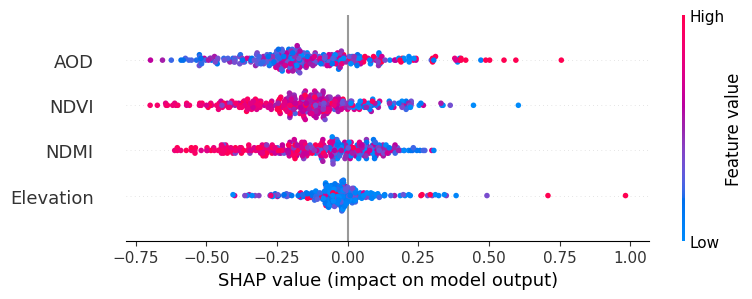

In [48]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Inisialisasi explainer
explainer = shap.KernelExplainer(model.predict, shap.kmeans(X_train_sel, 10))

# Hitung SHAP values
shap_values = explainer.shap_values(X_test_sel, nsamples=100)

# Plot summary (global interpretasi)
shap.summary_plot(shap_values, X_test_sel, feature_names=shared_features)


# Visualisasi

In [49]:
import folium
from folium import FeatureGroup
from google.colab import files

# === Siapkan data ===
df_test_2024 = data[data["year"] == 2024].copy()
df_test_2024["y_pred_test"] = y_pred_test
df_test_2024["target"] = y_pred_test

# Label dan warna
kelas_label = {0: "Rendah", 1: "Sedang", 2: "Tinggi"}
kelas_warna = {0: "#1f77b4", 1: "#ff7f0e", 2: "#d62728"}

# Tambahkan info label dan warna (untuk true & prediksi)
df_test_2024["label_true"] = df_test_2024["target"].map(kelas_label)
df_test_2024["color_true"] = df_test_2024["target"].map(kelas_warna)
df_test_2024["label_pred"] = df_test_2024["y_pred_test"].map(kelas_label)
df_test_2024["color_pred"] = df_test_2024["y_pred_test"].map(kelas_warna)

# Buat peta
map_center = [df_test_2024["latitude"].mean(), df_test_2024["longitude"].mean()]
m = folium.Map(location=map_center, zoom_start=6)

# Layer asli (true)
layer_true = FeatureGroup(name="Label Asli")
for _, row in df_test_2024.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        color=row["color_true"],
        fill=True,
        fill_color=row["color_true"],
        fill_opacity=0.6,
        popup=folium.Popup(f"<b>TPA:</b> {row['found_plac']}<br><b>Kategori Asli:</b> {row['label_true']}", max_width=250)
    ).add_to(layer_true)

# Layer prediksi
layer_pred = FeatureGroup(name="Hasil Prediksi")
for _, row in df_test_2024.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        color=row["color_pred"],
        fill=True,
        fill_color=row["color_pred"],
        fill_opacity=0.9,
        popup=folium.Popup(f"<b>TPA:</b> {row['found_plac']}<br><b>Prediksi:</b> {row['label_pred']}", max_width=250)
    ).add_to(layer_pred)

# Tambahkan kedua layer ke peta
layer_true.add_to(m)
layer_pred.add_to(m)

# Tambahkan kontrol layer (toggle)
folium.LayerControl().add_to(m)

# Tambahkan legenda
legend_html = """
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 180px; height: 120px;
    background-color: white; z-index:9999; font-size:14px;
    border:2px solid grey; padding: 10px;">
<b>Kategori Emisi:</b><br>
<i style="color:#1f77b4;">●</i> Rendah<br>
<i style="color:#ff7f0e;">●</i> Sedang<br>
<i style="color:#d62728;">●</i> Tinggi<br>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Simpan dan download
file_path = "peta_asli_vs_prediksi_2024.html"
m.save(file_path)
files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analisis Tambahan: KNN, Dummy/Majority Classifier, dan Sensitivity Analysis



In [50]:

# ============================================================
# ANALISIS TAMBAHAN - Helper Functions
# Tidak mengubah variabel/alur lama
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.neighbors import KNeighborsClassifier

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

if "shared_features" in globals():
    final_features = list(shared_features)
else:
    final_features = ["AOD", "Elevation", "NDVI", "NDMI"]

print("Fitur final yang digunakan:", final_features)

required_vars = [
    "X_train_scaled", "X_test_scaled",
    "y_train_cont", "y_test_cont",
    "y_train_cat", "y_test_cat",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "Variabel berikut belum ada. Jalankan cell preprocessing lama dulu: "
        + ", ".join(missing_vars)
    )

# ============================================================
# PENTING UNTUK ANALISIS TAMBAHAN
# Simpan salinan data awal sebelum SMOTE-Tomek lama.
# Notebook lama menimpa X_train menjadi hasil SMOTE-Tomek,
# jadi bagian analisis tambahan tidak memakai X_train untuk resampling.
# ============================================================
X_train_base = X_train_scaled.copy()
X_test_base = X_test_scaled.copy()
y_train_cont_base = y_train_cont.copy()
y_test_cont_base = y_test_cont.copy()
y_train_cat_base = pd.Series(y_train_cat).astype(int).copy()
y_test_cat_base = pd.Series(y_test_cat).astype(int).copy()

missing_features = [f for f in final_features if f not in X_train_base.columns]
if missing_features:
    raise ValueError(f"Fitur berikut tidak ada di X_train_scaled awal: {missing_features}")

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["Low", "Medium", "High"]
MAIN_MODEL_NAME = "KNN"


def to_int_series(y, name="CH4_Class"):
    """Pastikan label kelas berbentuk integer 0,1,2."""
    return pd.Series(y, name=name).astype(int).reset_index(drop=True)


def evaluate_model(y_true, y_pred):
    """Metrik utama untuk model dan baseline."""
    y_true = to_int_series(y_true)
    y_pred = to_int_series(y_pred)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
    }


# Best params KNN mengikuti notebook lama. Kalau variabel sudah ada dari cell lama, pakai variabel itu.
best_params_knn_used = globals().get(
    "best_params_knn",
    {"n_neighbors": 3, "weights": "uniform", "metric": "euclidean"}
)


def build_knn_from_best_params():
    """Bangun KNN dengan best params dari notebook lama."""
    params = deepcopy(best_params_knn_used)
    return KNeighborsClassifier(**params)


print("Helper analisis tambahan siap digunakan.")
print("Model yang dijalankan pada analisis tambahan:", MAIN_MODEL_NAME)
print("Data awal untuk sensitivity sebelum SMOTE-Tomek:", X_train_base.shape)


Fitur final yang digunakan: ['AOD', 'Elevation', 'NDVI', 'NDMI']
Helper analisis tambahan siap digunakan.
Model yang dijalankan pada analisis tambahan: KNN
Data awal untuk sensitivity sebelum SMOTE-Tomek: (736, 17)


In [56]:

# ============================================================
# ANALISIS TAMBAHAN 1
# Dummy Classifier dan Majority Classifier
# ============================================================

# Baseline analisis dilatih pada data training awal sebelum SMOTE-Tomek.
# Menunjukkan performa naive classifier pada distribusi kelas asli.
# Baseline tidak memakai SMOTE karena berfungsi sebagai pembanding sederhana/dummy-majority classifier.
X_train_baseline = X_train_base[final_features].copy()
X_test_baseline = X_test_base[final_features].copy()

y_train_baseline = to_int_series(y_train_cat_base)
y_test_baseline = to_int_series(y_test_cat_base)

baseline_models = {
    "MajorityClassifier": DummyClassifier(strategy="most_frequent", random_state=42),
    "DummyClassifier_Stratified": DummyClassifier(strategy="stratified", random_state=42),
}

baseline_rows = []

for baseline_name, baseline_model in baseline_models.items():
    baseline_model.fit(X_train_baseline, y_train_baseline)
    baseline_pred = baseline_model.predict(X_test_baseline)

    baseline_rows.append({
        "Model": baseline_name,
        "Model_Type": "Baseline",
        "Training_Data": "Original training set before SMOTE-Tomek",
        **evaluate_model(y_test_baseline, baseline_pred),
    })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_excel("Sensitivity_Baseline_Dummy_Majority_4FinalFeatures.xlsx", index=False)

print("📌 Baseline analisis:")
display(baseline_df.round(3))


# ============================================================
# Gabungkan dengan hasil KNN lama jika final_df tersedia
# SVM, RandomForest, dan XGBoost tidak ditampilkan pada bagian tambahan ini.
# ============================================================

if "final_df" in globals():
    final_model_df = final_df.copy()

    rename_cols = {
        "Test Accuracy": "Accuracy",
        "Test Precision Macro": "Precision_macro",
        "Test Recall Macro": "Recall_macro",
        "Test F1 Macro": "F1_macro",
        "Test F1 Weighted": "F1_weighted",
        "Test Balanced Accuracy": "Balanced_Accuracy",
    }

    final_model_df = final_model_df.rename(columns=rename_cols)

    # Ambil KNN saja dari hasil final model lama
    if "Model" in final_model_df.columns:
        final_model_df = final_model_df[
            final_model_df["Model"].astype(str).str.contains("KNN", case=False, na=False)
        ].copy()

    keep_cols = [
        "Model",
        "Accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "F1_weighted",
        "Balanced_Accuracy",
    ]

    final_model_df = final_model_df[
        [c for c in keep_cols if c in final_model_df.columns]
    ].copy()

    if not final_model_df.empty:
        final_model_df["Model_Type"] = "Main model"
        final_model_df["Training_Data"] = "SMOTE-Tomek training set from old notebook"

        model_comparison_df = pd.concat(
            [
                final_model_df,
                baseline_df[final_model_df.columns],
            ],
            ignore_index=True
        )
    else:
        print("KNN tidak ditemukan pada final_df. Tabel gabungan hanya berisi baseline.")
        model_comparison_df = baseline_df.copy()

else:
    model_comparison_df = baseline_df.copy()

model_comparison_df.to_excel(
    "Sensitivity_KNN_With_Dummy_Majority_4FinalFeatures.xlsx",
    index=False
)

print("📌 Tabel gabungan KNN + baseline:")
display(model_comparison_df.round(3))


📌 Baseline analisis:


,Model,Model_Type,Training_Data,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Balanced_Accuracy
0,MajorityClassifier,Baseline,Original training set before SMOTE-Tomek,0.864,0.288,0.333,0.309,0.801,0.333
1,DummyClassifier_Stratified,Baseline,Original training set before SMOTE-Tomek,0.785,0.410,0.378,0.383,0.783,0.378


📌 Tabel gabungan KNN + baseline:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Balanced_Accuracy,Model_Type,Training_Data
0,KNN,0.688,0.505,0.501,0.458,0.755,0.501,Main model,SMOTE-Tomek training set from old notebook
1,MajorityClassifier,0.864,0.288,0.333,0.309,0.801,0.333,Baseline,Original training set before SMOTE-Tomek
2,DummyClassifier_Stratified,0.785,0.410,0.378,0.383,0.783,0.378,Baseline,Original training set before SMOTE-Tomek


In [52]:

# ============================================================
# ANALISIS TAMBAHAN 2
# Sensitivity Analysis Threshold
# ============================================================

SENSITIVITY_SCENARIOS = {
    "Mean ±1 SD": {
        "method": "sd",
        "value": 1.0,
    },
    "Mean ±1.5 SD (Main)": {
        "method": "sd",
        "value": 1.5,
    },
    "Tertile Q33.3-Q66.7": {
        "method": "quantile",
        "low_q": 1/3,
        "high_q": 2/3,
    },
}


def create_threshold_labels(y_train_continuous, y_test_continuous, scenario):
    """Buat label Low/Medium/High berdasarkan threshold dari training set."""
    method = scenario["method"]

    if method == "sd":
        mean_train = float(y_train_continuous.mean())
        std_train = float(y_train_continuous.std())
        multiplier = float(scenario["value"])

        low_threshold_sens = mean_train - multiplier * std_train
        high_threshold_sens = mean_train + multiplier * std_train

        threshold_info = {
            "Method": "Mean ± SD",
            "Mean_train": mean_train,
            "Std_train": std_train,
            "Multiplier": multiplier,
            "Low_threshold": low_threshold_sens,
            "High_threshold": high_threshold_sens,
        }

    elif method == "quantile":
        low_q = float(scenario["low_q"])
        high_q = float(scenario["high_q"])

        low_threshold_sens = float(y_train_continuous.quantile(low_q))
        high_threshold_sens = float(y_train_continuous.quantile(high_q))

        threshold_info = {
            "Method": "Training quantile",
            "Mean_train": float(y_train_continuous.mean()),
            "Std_train": float(y_train_continuous.std()),
            "Multiplier": np.nan,
            "Low_quantile": low_q,
            "High_quantile": high_q,
            "Low_threshold": low_threshold_sens,
            "High_threshold": high_threshold_sens,
        }

    else:
        raise ValueError(f"Method tidak dikenali: {method}")

    def categorize_one(value):
        if value <= low_threshold_sens:
            return 0  # Low
        elif value >= high_threshold_sens:
            return 2  # High
        else:
            return 1  # Medium

    y_train_sens = y_train_continuous.apply(categorize_one).astype(int)
    y_test_sens = y_test_continuous.apply(categorize_one).astype(int)

    return y_train_sens, y_test_sens, threshold_info


def run_one_sensitivity(scenario_name, scenario):
    # 1. Bentuk label baru berdasarkan threshold dari training set
    y_train_sens, y_test_sens, threshold_info = create_threshold_labels(
        y_train_cont_base,
        y_test_cont_base,
        scenario,
    )

    train_counts = (
        y_train_sens
        .value_counts()
        .reindex(CLASS_LABELS, fill_value=0)
        .rename(index={0: "Low", 1: "Medium", 2: "High"})
    )

    test_counts = (
        y_test_sens
        .value_counts()
        .reindex(CLASS_LABELS, fill_value=0)
        .rename(index={0: "Low", 1: "Medium", 2: "High"})
    )

    min_class_count = int(train_counts.min())

    if min_class_count < 2:
        raise ValueError(
            f"{scenario_name}: kelas terkecil pada training hanya {min_class_count}. "
            "SMOTE membutuhkan minimal 2 observasi."
        )

    smote_k = min(2, max(1, min_class_count - 1))

    smote_sens = SMOTE(k_neighbors=smote_k, random_state=42)
    smote_tomek_sens = SMOTETomek(smote=smote_sens, random_state=42)

    # 2. Gunakan split train-test yang sama dan ambil 4 fitur final
    X_train_sens_raw_4features = X_train_base[final_features].copy()
    X_test_sens_model = X_test_base[final_features].copy()

    # 3. SMOTE-Tomek ulang pada 4 fitur final saja
    X_resampled_sens, y_resampled_sens = smote_tomek_sens.fit_resample(
        X_train_sens_raw_4features,
        y_train_sens,
    )

    X_train_sens_model = pd.DataFrame(
        X_resampled_sens,
        columns=final_features,
    )

    y_resampled_sens = to_int_series(y_resampled_sens)

    resampled_counts = (
        y_resampled_sens
        .value_counts()
        .reindex(CLASS_LABELS, fill_value=0)
        .rename(index={0: "Low", 1: "Medium", 2: "High"})
    )

    result_rows = []

    # 4. Latih KNN pada hasil SMOTE-Tomek 4 fitur
    knn_model = build_knn_from_best_params()
    knn_model.fit(X_train_sens_model, y_resampled_sens)
    knn_pred = knn_model.predict(X_test_sens_model)

    result_rows.append({
        "Threshold_Scenario": scenario_name,
        "Model": "KNN",
        "Model_Type": "Main model",
        "Training_Data": "SMOTE-Tomek on 4 final features",
        **evaluate_model(y_test_sens, knn_pred),
    })

    # 5. Majority classifier: original training distribution, tanpa SMOTE
    majority_model = DummyClassifier(strategy="most_frequent", random_state=42)
    majority_model.fit(X_train_sens_raw_4features, y_train_sens)
    majority_pred = majority_model.predict(X_test_sens_model)

    result_rows.append({
        "Threshold_Scenario": scenario_name,
        "Model": "MajorityClassifier",
        "Model_Type": "Baseline",
        "Training_Data": "Original 4 final features before SMOTE-Tomek",
        **evaluate_model(y_test_sens, majority_pred),
    })

    # 6. Dummy stratified classifier: original training distribution, tanpa SMOTE
    dummy_stratified = DummyClassifier(strategy="stratified", random_state=42)
    dummy_stratified.fit(X_train_sens_raw_4features, y_train_sens)
    dummy_pred = dummy_stratified.predict(X_test_sens_model)

    result_rows.append({
        "Threshold_Scenario": scenario_name,
        "Model": "DummyClassifier_Stratified",
        "Model_Type": "Baseline",
        "Training_Data": "Original 4 final features before SMOTE-Tomek",
        **evaluate_model(y_test_sens, dummy_pred),
    })

    threshold_row = {
        "Threshold_Scenario": scenario_name,
        **threshold_info,
        "SMOTE_k_neighbors": smote_k,
        "SMOTE_Source": "4 final features from X_train_scaled before old SMOTE-Tomek",
        "SMOTE_Features": ", ".join(final_features),
        "Train_Low": int(train_counts.loc["Low"]),
        "Train_Medium": int(train_counts.loc["Medium"]),
        "Train_High": int(train_counts.loc["High"]),
        "Test_Low": int(test_counts.loc["Low"]),
        "Test_Medium": int(test_counts.loc["Medium"]),
        "Test_High": int(test_counts.loc["High"]),
        "Train_Total": int(train_counts.sum()),
        "Test_Total": int(test_counts.sum()),
        "Resampled_Low": int(resampled_counts.loc["Low"]),
        "Resampled_Medium": int(resampled_counts.loc["Medium"]),
        "Resampled_High": int(resampled_counts.loc["High"]),
        "Resampled_Train_Total": int(len(y_resampled_sens)),
    }

    return result_rows, threshold_row


sensitivity_all_rows = []
sensitivity_threshold_rows = []

for scenario_name, scenario in SENSITIVITY_SCENARIOS.items():
    print(f"Running sensitivity scenario for KNN and dummy classifiers: {scenario_name}")

    rows, threshold_row = run_one_sensitivity(
        scenario_name,
        scenario,
    )

    sensitivity_all_rows.extend(rows)
    sensitivity_threshold_rows.append(threshold_row)

sensitivity_metrics_df = pd.DataFrame(sensitivity_all_rows)
sensitivity_thresholds_df = pd.DataFrame(sensitivity_threshold_rows)

scenario_order = list(SENSITIVITY_SCENARIOS.keys())
model_order = [
    "KNN",
    "MajorityClassifier",
    "DummyClassifier_Stratified",
]

sensitivity_metrics_df["Threshold_Scenario"] = pd.Categorical(
    sensitivity_metrics_df["Threshold_Scenario"],
    categories=scenario_order,
    ordered=True,
)

sensitivity_metrics_df["Model"] = pd.Categorical(
    sensitivity_metrics_df["Model"],
    categories=model_order,
    ordered=True,
)

sensitivity_metrics_df = (
    sensitivity_metrics_df
    .sort_values(["Threshold_Scenario", "Model"])
    .reset_index(drop=True)
)

sensitivity_thresholds_df["Threshold_Scenario"] = pd.Categorical(
    sensitivity_thresholds_df["Threshold_Scenario"],
    categories=scenario_order,
    ordered=True,
)

sensitivity_thresholds_df = (
    sensitivity_thresholds_df
    .sort_values("Threshold_Scenario")
    .reset_index(drop=True)
)

sensitivity_metrics_df.to_excel(
    "Sensitivity_KNN_Dummy_4FinalFeatures.xlsx",
    index=False,
)

sensitivity_thresholds_df.to_excel(
    "Sensitivity_Threshold_Details_KNN_Dummy_4FinalFeatures.xlsx",
    index=False,
)

print("📌 Detail threshold sensitivity:")
display(sensitivity_thresholds_df)

print("📌 Hasil sensitivity analysis KNN vs dummy classifier:")
display(sensitivity_metrics_df.round(3))


Running sensitivity scenario for KNN and dummy classifiers: Mean ±1 SD
Running sensitivity scenario for KNN and dummy classifiers: Mean ±1.5 SD (Main)
Running sensitivity scenario for KNN and dummy classifiers: Tertile Q33.3-Q66.7
📌 Detail threshold sensitivity:


,Threshold_Scenario,Method,Mean_train,Std_train,Multiplier,Low_threshold,High_threshold,SMOTE_k_neighbors,SMOTE_Source,SMOTE_Features,Train_Low,Train_Medium,Train_High,Test_Low,Test_Medium,Test_High,Train_Total,Test_Total,Resampled_Low,Resampled_Medium,Resampled_High,Resampled_Train_Total,Low_quantile,High_quantile
0,Mean ±1 SD,Mean ± SD,1859.406876,22.120095,1.0,1837.286781,1881.526971,2,4 final features from X_train_scaled before ol...,"AOD, Elevation, NDVI, NDMI",115,508,113,19,195,103,736,317,491,485,496,1472,NaN,NaN
1,Mean ±1.5 SD (Main),Mean ± SD,1859.406876,22.120095,1.5,1826.226733,1892.587018,2,4 final features from X_train_scaled before ol...,"AOD, Elevation, NDVI, NDMI",48,659,29,11,274,32,736,317,656,655,658,1969,NaN,NaN
2,Tertile Q33.3-Q66.7,Training quantile,1859.406876,22.120095,NaN,1850.403054,1871.270048,2,4 final features from X_train_scaled before ol...,"AOD, Elevation, NDVI, NDMI",246,244,246,35,96,186,736,317,161,174,173,508,0.333333,0.666667


📌 Hasil sensitivity analysis KNN vs dummy classifier:


,Threshold_Scenario,Model,Model_Type,Training_Data,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Balanced_Accuracy
0,Mean ±1 SD,KNN,Main model,SMOTE-Tomek on 4 final features,0.508,0.459,0.456,0.420,0.559,0.456
1,Mean ±1 SD,MajorityClassifier,Baseline,Original 4 final features before SMOTE-Tomek,0.615,0.205,0.333,0.254,0.469,0.333
2,Mean ±1 SD,DummyClassifier_Stratified,Baseline,Original 4 final features before SMOTE-Tomek,0.473,0.342,0.387,0.330,0.460,0.387
3,Mean ±1.5 SD (Main),KNN,Main model,SMOTE-Tomek on 4 final features,0.710,0.468,0.404,0.422,0.766,0.404
4,Mean ±1.5 SD (Main),MajorityClassifier,Baseline,Original 4 final features before SMOTE-Tomek,0.864,0.288,0.333,0.309,0.801,0.333
5,Mean ±1.5 SD (Main),DummyClassifier_Stratified,Baseline,Original 4 final features before SMOTE-Tomek,0.785,0.410,0.378,0.383,0.783,0.378
6,Tertile Q33.3-Q66.7,KNN,Main model,SMOTE-Tomek on 4 final features,0.350,0.395,0.370,0.325,0.398,0.370
7,Tertile Q33.3-Q66.7,MajorityClassifier,Baseline,Original 4 final features before SMOTE-Tomek,0.110,0.037,0.333,0.066,0.022,0.333
8,Tertile Q33.3-Q66.7,DummyClassifier_Stratified,Baseline,Original 4 final features before SMOTE-Tomek,0.315,0.320,0.308,0.283,0.351,0.308


,Threshold_Scenario,Model,Model_Type,Accuracy,F1_macro,F1_weighted,Balanced_Accuracy
0,Mean ±1 SD,KNN,Main model,0.508,0.420,0.559,0.456
1,Mean ±1 SD,MajorityClassifier,Baseline,0.615,0.254,0.469,0.333
2,Mean ±1 SD,DummyClassifier_Stratified,Baseline,0.473,0.330,0.460,0.387
3,Mean ±1.5 SD (Main),KNN,Main model,0.710,0.422,0.766,0.404
4,Mean ±1.5 SD (Main),MajorityClassifier,Baseline,0.864,0.309,0.801,0.333
5,Mean ±1.5 SD (Main),DummyClassifier_Stratified,Baseline,0.785,0.383,0.783,0.378
6,Tertile Q33.3-Q66.7,KNN,Main model,0.350,0.325,0.398,0.370
7,Tertile Q33.3-Q66.7,MajorityClassifier,Baseline,0.110,0.066,0.022,0.333
8,Tertile Q33.3-Q66.7,DummyClassifier_Stratified,Baseline,0.315,0.283,0.351,0.308


/tmp/ipykernel_2271/2187067072.py:29: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_f1 = plot_df.pivot_table(


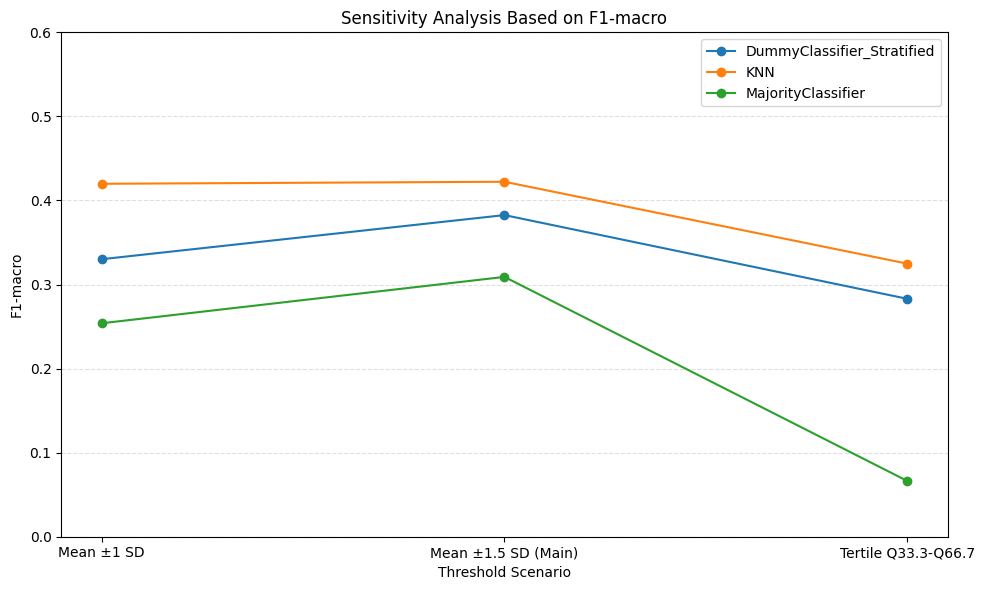

File analisis tambahan tersimpan:
- Sensitivity_Baseline_Dummy_Majority_4FinalFeatures.xlsx
- Sensitivity_KNN_With_Dummy_Majority_4FinalFeatures.xlsx
- Sensitivity_KNN_Dummy_4FinalFeatures.xlsx
- Sensitivity_Threshold_Details_KNN_Dummy_4FinalFeatures.xlsx
- Sensitivity_Summary_KNN_Dummy_4FinalFeatures.xlsx
- Sensitivity_F1macro_KNN_Dummy_4FinalFeatures.png


In [53]:

# ============================================================
# Ringkasan Sensitivity untuk Artikel
# ============================================================

summary_cols = [
    "Threshold_Scenario",
    "Model",
    "Model_Type",
    "Accuracy",
    "F1_macro",
    "F1_weighted",
    "Balanced_Accuracy",
]

sensitivity_summary_for_paper = sensitivity_metrics_df[summary_cols].copy()

sensitivity_summary_for_paper.to_excel(
    "Sensitivity_Summary_KNN_Dummy_4FinalFeatures.xlsx",
    index=False,
)

display(sensitivity_summary_for_paper.round(3))


# Plot sederhana F1-macro sensitivity
plot_df = sensitivity_summary_for_paper.copy()
plot_df["Model"] = plot_df["Model"].astype(str)

pivot_f1 = plot_df.pivot_table(
    index="Threshold_Scenario",
    columns="Model",
    values="F1_macro",
    aggfunc="mean"
).loc[list(SENSITIVITY_SCENARIOS.keys())]

plt.figure(figsize=(10, 6))

for model_name in pivot_f1.columns:
    plt.plot(
        pivot_f1.index.astype(str),
        pivot_f1[model_name],
        marker="o",
        label=model_name,
    )

plt.title("Sensitivity Analysis Based on F1-macro")
plt.xlabel("Threshold Scenario")
plt.ylabel("F1-macro")
plt.ylim(0, max(0.6, np.nanmax(pivot_f1.to_numpy()) + 0.08))
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("Sensitivity_F1macro_KNN_Dummy_4FinalFeatures.png", dpi=300, bbox_inches="tight")
plt.show()

print("File analisis tambahan tersimpan:")
print("- Sensitivity_Baseline_Dummy_Majority_4FinalFeatures.xlsx")
print("- Sensitivity_KNN_With_Dummy_Majority_4FinalFeatures.xlsx")
print("- Sensitivity_KNN_Dummy_4FinalFeatures.xlsx")
print("- Sensitivity_Threshold_Details_KNN_Dummy_4FinalFeatures.xlsx")
print("- Sensitivity_Summary_KNN_Dummy_4FinalFeatures.xlsx")
print("- Sensitivity_F1macro_KNN_Dummy_4FinalFeatures.png")


In [55]:
from pathlib import Path
import zipfile
from datetime import datetime

if "OUTPUT_DIR" in globals():
    SOURCE_DIR = Path(OUTPUT_DIR)
else:
    SOURCE_DIR = Path(".")

print("Folder yang akan dizip:", SOURCE_DIR.resolve())

# Nama file zip
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_filename = f"Output_Runtime_{timestamp}.zip"
zip_path = Path(zip_filename)

# Ekstensi output yang mau ikut dizip
allowed_extensions = {
    ".xlsx", ".csv", ".png", ".jpg", ".jpeg",
    ".pdf", ".json", ".txt", ".pkl", ".joblib",
    ".html", ".ipynb"
}

skip_parts = {
    ".ipynb_checkpoints",
    "__pycache__",
    "sample_data",
}

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in SOURCE_DIR.rglob("*"):
        if file_path.is_file():
            # skip folder sampah/cache
            if any(part in skip_parts for part in file_path.parts):
                continue

            # hanya ambil file output tertentu
            if file_path.suffix.lower() in allowed_extensions:
                arcname = file_path.relative_to(SOURCE_DIR)
                zipf.write(file_path, arcname=arcname)

print("ZIP selesai dibuat:", zip_path.resolve())

from google.colab import files

files.download(str(zip_path))

Folder yang akan dizip: /content
ZIP selesai dibuat: /content/Output_Runtime_20260716_024032.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>